# Klasifikasi Degradasi Hutan TNBBS dengan EfficientNet-B4

### Bagian 1 — Persiapan dan Pengolahan Dataset

1. Instalasi dan Import
2. Konfigurasi Eksperimen
3. Inventaris dan Validasi Input
4. Membaca dan Membersihkan Metadata
5. Stratified Spatial Group Split berdasarkan `grid_id`
6. Ekstraksi Patch RGB dari GeoTIFF
7. Visualisasi Grid, Patch, Metadata, dan Distribusi Dataset
8. Dataset dan DataLoader
9. Visual Augmentasi pada data Degradasi

### Bagian 2 — Pengembangan dan Pelatihan Model

10. EfficientNet-B4 Pretrained dan Focal Loss
11. Fungsi Training, Validasi, dan Early Stopping
12. Fase 1 — Feature Extraction
13. Fase 2 — Fine-Tuning Konservatif Sebagian Backbone
14. Kurva Pembelajaran

### Bagian 3 — Evaluasi dan Analisis Kinerja Model

15. Evaluasi Final pada Test Set
16. Natural Test, Balanced Diagnostic Test, dan Bootstrap CI

### Bagian 4 — Explainability dan Penyimpanan Hasil

17. Bukti Degradasi Grad-CAM dan Perbandingan Temporal
18. Penyimpanan Artefak Inti

## Bagian 1 — Persiapan dan Pengolahan Dataset


### 1. Instalasi dan Import


In [20]:
import gc
import glob
import json
import math
import random
import re
import subprocess
import sys
import time
import warnings
from collections import Counter
from contextlib import nullcontext
from pathlib import Path

try:
    import rasterio
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio"])
    import rasterio

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from rasterio.windows import from_bounds
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from IPython.display import display
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


### 2. Konfigurasi Eksperimen

In [21]:
INPUT_DIR = Path("/kaggle/input/datasets/eichaleg/dataset-degradasi")
OUTPUT_DIR = Path("/kaggle/working/tnbbs-output-degradation-augmentation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_MONTHS = 31
EXPECTED_CSV_FILES = 3
PATCH_SIZE = 128
PIXEL_SIZE_M = 10
PATCH_HALF_M = PATCH_SIZE * PIXEL_SIZE_M / 2
RGB_BANDS = (1, 2, 3)  # GeoTIFF diekspor dalam urutan B4, B3, B2.
REFLECTANCE_STRETCH = 3000.0
MAX_NODATA_FRACTION = 0.20

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42
DIAGNOSTIC_SEED = 31415
BOOTSTRAP_SEED = 27182
BOOTSTRAP_ITERATIONS = 1000

IMAGE_SIZE = 380
NUM_CLASSES = 2
BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 2
# Patch sudah berada di RAM. Pada runtime Kaggle ini multiprocessing DataLoader
# justru membuat CPU penuh dan GPU menunggu, sehingga batching dilakukan oleh
# proses utama dan seluruh transformasi numerik dipindahkan ke GPU.
NUM_WORKERS = 0
USE_AMP = True

# Train mempertahankan distribusi kelas alami; hanya kelas degradasi mendapat virtual copy.
# Augmentasi minoritas: data asli tidak dibuang. Satu virtual copy degradasi
# ditambahkan pada train dan berubah setiap epoch. Validation/test tetap asli.
DEGRADATION_AUGMENTED_COPIES = 1
DEGRADATION_CROP_PROBABILITY = 0.70
DEGRADATION_CROP_MIN_AREA_SCALE = 0.90
# Crop hanya untuk label degradasi yang degraded_fraction-nya minimal 3%.
# Rotasi/flip tetap dapat digunakan pada sampel degradasi 2-3%.
DEGRADATION_CROP_MIN_FRACTION = 0.03

EPOCHS_PHASE_1 = 3
EPOCHS_PHASE_2 = 10
LR_PHASE_1 = 1e-4
# Fine-tuning memakai learning rate diskriminatif: bobot pretrained bergerak
# lebih hati-hati daripada classifier yang baru dilatih.
LR_PHASE_2_BACKBONE = 1e-5
LR_PHASE_2_CLASSIFIER = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.4
EARLY_STOPPING_PATIENCE = 4
LR_SCHEDULER_PATIENCE = 1
CHECKPOINT_MONITOR = "pr_auc"
CHECKPOINT_MODE = "max"
CHECKPOINT_MIN_DELTA = 1e-4
UNFREEZE_FROM = 6
MAX_GRAD_NORM = 1.0
FREEZE_BACKBONE_BATCHNORM_STATS = True

FOCAL_GAMMA = 2.0
# None berarti Focal Loss tanpa bobot kelas tambahan. Jangan sekaligus memakai
# inverse-frequency ekstrem dan weighted sampler tanpa eksperimen validasi.
FOCAL_ALPHA = None

SAVE_PATCH_CACHE = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")
PIN_MEMORY = DEVICE.type == "cuda"


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Heuristik cuDNN menghindari autotuning panjang pada awal training.
    # Seed tetap dipasang, tetapi hasil antarrun dapat berbeda sangat kecil.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "GPU tidak aktif. Pilih Kaggle Settings > Accelerator > GPU P100 "
        "atau GPU T4 x2, "
        "restart session, lalu Run All. Training CPU sengaja dihentikan."
    )


### 3. Inventaris dan Validasi Input


In [22]:
if not INPUT_DIR.exists():
    available_inputs = sorted(str(path) for path in Path("/kaggle/input").glob("*"))
    raise FileNotFoundError(
        f"Folder {INPUT_DIR} tidak ditemukan. Input Kaggle yang tersedia: {available_inputs}"
    )


def discover_yearly_csv(input_dir):
    paths = sorted(input_dir.rglob("metadata_patches_*.csv"))
    yearly_pattern = re.compile(r"metadata_patches_(2024|2025|2026)\.csv$", re.I)
    yearly_paths = [path for path in paths if yearly_pattern.fullmatch(path.name)]
    if len(yearly_paths) != EXPECTED_CSV_FILES:
        raise ValueError(
            f"Diharapkan {EXPECTED_CSV_FILES} CSV tahunan, ditemukan {len(yearly_paths)}: "
            f"{[path.name for path in yearly_paths]}"
        )
    return yearly_paths


def discover_monthly_tifs(input_dir):
    pattern = re.compile(r"mosaic_multiband_(\d{4}_\d{2})\.tif$", re.I)
    tif_map = {}
    for path in sorted(input_dir.rglob("mosaic_multiband_*.tif")):
        match = pattern.fullmatch(path.name)
        if not match:
            continue
        target_month = match.group(1)
        if target_month in tif_map:
            raise ValueError(
                f"GeoTIFF ganda untuk {target_month}: {tif_map[target_month]} dan {path}"
            )
        tif_map[target_month] = path
    if len(tif_map) != EXPECTED_MONTHS:
        raise ValueError(
            f"Diharapkan {EXPECTED_MONTHS} GeoTIFF, ditemukan {len(tif_map)}. "
            f"Bulan tersedia: {sorted(tif_map)}"
        )
    return tif_map


CSV_PATHS = discover_yearly_csv(INPUT_DIR)
TIF_BY_MONTH = discover_monthly_tifs(INPUT_DIR)

print("CSV tahunan:")
for path in CSV_PATHS:
    print(" -", path)
print(f"GeoTIFF bulanan: {len(TIF_BY_MONTH)} file")
print("Rentang bulan   :", min(TIF_BY_MONTH), "s.d.", max(TIF_BY_MONTH))


CSV tahunan:
 - /kaggle/input/datasets/eichaleg/dataset-degradasi/metadata_patches_2024.csv
 - /kaggle/input/datasets/eichaleg/dataset-degradasi/metadata_patches_2025.csv
 - /kaggle/input/datasets/eichaleg/dataset-degradasi/metadata_patches_2026.csv
GeoTIFF bulanan: 31 file
Rentang bulan   : 2024_01 s.d. 2026_07


### 4. Membaca dan Membersihkan Metadata

In [23]:
REQUIRED_COLUMNS = [
    "grid_id",
    "target_month",
    "year",
    "month",
    "label",
    "label_name",
    "degraded_fraction",
    "healthy_fraction",
    "clear_fraction",
    "forest_fraction",
    "valid_forest_fraction",
    "mean_ndvi",
    "hansen_fraction",
    "hansen_available",
    "lon",
    "lat",
    "x_utm",
    "y_utm",
]

FRACTION_COLUMNS = [
    "degraded_fraction",
    "healthy_fraction",
    "clear_fraction",
    "forest_fraction",
    "valid_forest_fraction",
    "hansen_fraction",
]

NUMERIC_COLUMNS = [
    "year",
    "month",
    "label",
    "mean_ndvi",
    "hansen_available",
    "lon",
    "lat",
    "x_utm",
    "y_utm",
] + FRACTION_COLUMNS


def load_and_validate_metadata(csv_paths):
    frames = []
    for path in csv_paths:
        frame = pd.read_csv(path)
        missing = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
        if missing:
            raise ValueError(f"Kolom hilang pada {path.name}: {missing}")
        frame = frame[REQUIRED_COLUMNS].copy()
        frame["source_csv"] = path.name
        frames.append(frame)

    metadata = pd.concat(frames, ignore_index=True)
    metadata["grid_id"] = metadata["grid_id"].astype(str)
    metadata["target_month"] = metadata["target_month"].astype(str)

    for column in NUMERIC_COLUMNS:
        metadata[column] = pd.to_numeric(metadata[column], errors="coerce")

    if metadata[REQUIRED_COLUMNS].isna().any().any():
        null_counts = metadata[REQUIRED_COLUMNS].isna().sum()
        raise ValueError(f"Nilai kosong/tidak numerik ditemukan:\n{null_counts[null_counts > 0]}")

    for column in FRACTION_COLUMNS:
        outside = ~metadata[column].between(0, 1)
        if outside.any():
            print(
                f"Sanitasi {column}: {outside.sum()} nilai di luar [0,1]; "
                f"rentang awal=({metadata[column].min():.6f}, {metadata[column].max():.6f})"
            )
            metadata[column] = metadata[column].clip(0, 1)

    metadata["year"] = metadata["year"].astype(int)
    metadata["month"] = metadata["month"].astype(int)
    metadata["label"] = metadata["label"].astype(int)
    metadata["hansen_available"] = metadata["hansen_available"].astype(int)

    expected_target_month = (
        metadata["year"].astype(str) + "_" + metadata["month"].astype(str).str.zfill(2)
    )
    if not metadata["target_month"].equals(expected_target_month):
        raise ValueError("Kolom target_month tidak konsisten dengan year dan month")

    if not set(metadata["label"].unique()).issubset({0, 1}):
        raise ValueError(f"Label selain 0/1 ditemukan: {sorted(metadata['label'].unique())}")

    duplicate_count = metadata.duplicated(["grid_id", "target_month"]).sum()
    if duplicate_count:
        raise ValueError(f"Ditemukan {duplicate_count} duplikasi grid_id + target_month")

    available_months = set(metadata["target_month"].unique())
    missing_tifs = sorted(available_months - set(TIF_BY_MONTH))
    if missing_tifs:
        raise ValueError(f"Metadata tidak memiliki pasangan GeoTIFF: {missing_tifs}")

    qc_violations = {
        "clear_fraction < 0.80": int((metadata["clear_fraction"] < 0.80 - 1e-9).sum()),
        "forest_fraction < 0.50": int((metadata["forest_fraction"] < 0.50 - 1e-9).sum()),
        "valid_forest_fraction < 0.80": int(
            (metadata["valid_forest_fraction"] < 0.80 - 1e-9).sum()
        ),
        "label 1 tetapi degraded_fraction < 0.02": int(
            ((metadata["label"] == 1) & (metadata["degraded_fraction"] < 0.02 - 1e-9)).sum()
        ),
        "label 0 tetapi degraded_fraction > 0.005": int(
            ((metadata["label"] == 0) & (metadata["degraded_fraction"] > 0.005 + 1e-9)).sum()
        ),
        "label 0 tetapi healthy_fraction < 0.50": int(
            ((metadata["label"] == 0) & (metadata["healthy_fraction"] < 0.50 - 1e-9)).sum()
        ),
    }
    if any(qc_violations.values()):
        raise ValueError(f"Pelanggaran QC/label ditemukan: {qc_violations}")

    return metadata.sort_values(["target_month", "grid_id"]).reset_index(drop=True)


metadata = load_and_validate_metadata(CSV_PATHS)

print(f"Jumlah metadata : {len(metadata):,}")
print(f"Grid unik       : {metadata['grid_id'].nunique():,}")
print(f"Bulan unik      : {metadata['target_month'].nunique()}")
print("Distribusi label:")
print(metadata["label_name"].value_counts())


Sanitasi healthy_fraction: 96 nilai di luar [0,1]; rentang awal=(0.000000, 1.003327)
Jumlah metadata : 24,949
Grid unik       : 1,413
Bulan unik      : 31
Distribusi label:
label_name
hutan_sehat    24390
degradasi        559
Name: count, dtype: int64


### 5. Stratified Spatial Group Split berdasarkan `grid_id`

In [24]:
grid_table = (
    metadata.groupby("grid_id", as_index=False)
    .agg(
        has_degradation=("label", "max"),
        observation_count=("label", "size"),
    )
    .sort_values("grid_id")
    .reset_index(drop=True)
)

train_grids, temporary_grids = train_test_split(
    grid_table,
    train_size=TRAIN_RATIO,
    random_state=SEED,
    stratify=grid_table["has_degradation"],
)

val_grids, test_grids = train_test_split(
    temporary_grids,
    train_size=0.5,
    random_state=SEED,
    stratify=temporary_grids["has_degradation"],
)

split_grid_sets = {
    "train": set(train_grids["grid_id"]),
    "val": set(val_grids["grid_id"]),
    "test": set(test_grids["grid_id"]),
}

assert split_grid_sets["train"].isdisjoint(split_grid_sets["val"])
assert split_grid_sets["train"].isdisjoint(split_grid_sets["test"])
assert split_grid_sets["val"].isdisjoint(split_grid_sets["test"])
assert set.union(*split_grid_sets.values()) == set(grid_table["grid_id"])

grid_to_split = {
    grid_id: split_name
    for split_name, grid_ids in split_grid_sets.items()
    for grid_id in grid_ids
}
metadata["spatial_split"] = metadata["grid_id"].map(grid_to_split)

grid_table["spatial_split"] = grid_table["grid_id"].map(grid_to_split)
grid_table.to_csv(OUTPUT_DIR / "split_assignment_by_grid.csv", index=False)

grid_split_summary = pd.crosstab(
    grid_table["spatial_split"], grid_table["has_degradation"], margins=True
).rename(columns={0: "healthy_only_grid", 1: "ever_degraded_grid"})

row_split_summary = pd.crosstab(
    metadata["spatial_split"], metadata["label"], margins=True
).rename(columns={0: "healthy_rows", 1: "degraded_rows"})

print("Ringkasan grid per split:")
display(grid_split_summary)
print("Ringkasan baris metadata per split:")
display(row_split_summary)


Ringkasan grid per split:


has_degradation,healthy_only_grid,ever_degraded_grid,All
spatial_split,,,
test,188,24,212
train,877,112,989
val,188,24,212
All,1253,160,1413


Ringkasan baris metadata per split:


label,healthy_rows,degraded_rows,All
spatial_split,,,
test,3581,78,3659
train,17012,390,17402
val,3797,91,3888
All,24390,559,24949


### 6. Ekstraksi Patch RGB dari GeoTIFF

In [25]:
def patch_window_from_center(src, x_utm, y_utm):
    left = float(x_utm) - PATCH_HALF_M
    right = float(x_utm) + PATCH_HALF_M
    bottom = float(y_utm) - PATCH_HALF_M
    top = float(y_utm) + PATCH_HALF_M
    window = from_bounds(left, bottom, right, top, transform=src.transform)
    return window.round_offsets().round_lengths()


def read_and_prepare_patch(src, x_utm, y_utm):
    window = patch_window_from_center(src, x_utm, y_utm)
    if int(window.width) != PATCH_SIZE or int(window.height) != PATCH_SIZE:
        return None, None, "window_shape"

    patch_masked = src.read(
        list(RGB_BANDS),
        window=window,
        boundless=True,
        masked=True,
        fill_value=src.nodata if src.nodata is not None else -9999,
    )
    if patch_masked.shape != (len(RGB_BANDS), PATCH_SIZE, PATCH_SIZE):
        return None, None, "patch_shape"

    data = np.asarray(patch_masked.data, dtype=np.float32)
    mask = np.ma.getmaskarray(patch_masked)
    invalid = mask.any(axis=0) | (~np.isfinite(data)).any(axis=0) | (data < 0).any(axis=0)
    nodata_fraction = float(invalid.mean())

    if nodata_fraction > MAX_NODATA_FRACTION + 1e-6:
        return None, nodata_fraction, "too_much_nodata"

    valid = ~invalid
    if not valid.any():
        return None, nodata_fraction, "all_nodata"

    for band_index in range(data.shape[0]):
        fill_value = float(np.median(data[band_index][valid]))
        data[band_index][invalid] = fill_value

    # Linear stretch reflectance 0..3000 menjadi RGB 0..255, lalu langsung uint8.
    data = np.rint(np.clip(data / REFLECTANCE_STRETCH, 0, 1) * 255).astype(np.uint8)
    return data, nodata_fraction, None


def extract_all_patches(metadata_frame, tif_by_month):
    patch_list = []
    label_list = []
    kept_rows = []
    skipped = Counter()

    for target_month, month_frame in metadata_frame.groupby("target_month", sort=True):
        tif_path = tif_by_month[target_month]
        with rasterio.open(tif_path) as src:
            if src.count < 3:
                raise ValueError(f"{tif_path.name} hanya memiliki {src.count} band")
            if any(dtype.lower() != "int16" for dtype in src.dtypes[:3]):
                raise ValueError(
                    f"Tiga band RGB {tif_path.name} harus Int16, ditemukan {src.dtypes[:3]}"
                )
            if src.crs is None or src.crs.to_epsg() != 32748:
                raise ValueError(f"CRS {tif_path.name} bukan EPSG:32748: {src.crs}")
            if not np.allclose([abs(src.res[0]), abs(src.res[1])], [10, 10], atol=1e-6):
                raise ValueError(f"Resolusi {tif_path.name} bukan 10 m: {src.res}")
            if src.nodata != -9999:
                print(f"Peringatan: NoData {tif_path.name} adalah {src.nodata}, bukan -9999")

            iterator = tqdm(
                month_frame.to_dict("records"),
                desc=f"Crop {target_month}",
                leave=False,
            )
            for row in iterator:
                patch, nodata_fraction, reason = read_and_prepare_patch(
                    src, row["x_utm"], row["y_utm"]
                )
                if reason is not None:
                    skipped[reason] += 1
                    continue

                row["rgb_nodata_fraction"] = nodata_fraction
                patch_list.append(patch)
                label_list.append(int(row["label"]))
                kept_rows.append(row)

    if not patch_list:
        raise RuntimeError("Tidak ada patch valid yang berhasil diekstrak")

    patches_array = np.stack(patch_list).astype(np.uint8, copy=False)
    labels_array = np.asarray(label_list, dtype=np.int64)
    kept_metadata = pd.DataFrame(kept_rows).reset_index(drop=True)

    if kept_metadata.duplicated(["grid_id", "target_month"]).any():
        raise RuntimeError("Duplikasi muncul setelah ekstraksi patch")
    if set(labels_array.tolist()) != {0, 1}:
        raise RuntimeError(f"Kedua kelas tidak lengkap setelah ekstraksi: {Counter(labels_array)}")
    if set(kept_metadata["spatial_split"]) != {"train", "val", "test"}:
        raise RuntimeError("Split tidak lengkap setelah ekstraksi")

    print("Patch dibuang:", dict(skipped))
    return patches_array, labels_array, kept_metadata


cache_patch_path = OUTPUT_DIR / "patches_uint8.npy"
cache_label_path = OUTPUT_DIR / "labels.npy"
cache_metadata_path = OUTPUT_DIR / "metadata_extracted.csv"

if (
    SAVE_PATCH_CACHE
    and cache_patch_path.exists()
    and cache_label_path.exists()
    and cache_metadata_path.exists()
):
    print("Memuat cache patch dari /kaggle/working")
    patches = np.load(cache_patch_path, mmap_mode="r")
    labels = np.load(cache_label_path)
    extracted_metadata = pd.read_csv(cache_metadata_path)
else:
    patches, labels, extracted_metadata = extract_all_patches(metadata, TIF_BY_MONTH)
    extracted_metadata.to_csv(cache_metadata_path, index=False)
    if SAVE_PATCH_CACHE:
        np.save(cache_patch_path, patches)
        np.save(cache_label_path, labels)

print(f"Patch valid      : {len(patches):,}")
print(f"Shape            : {patches.shape}")
print(f"Memori patch     : {patches.nbytes / 1024**3:.2f} GB")
print(f"Distribusi label : {dict(Counter(labels))}")
print("Distribusi split:")
display(pd.crosstab(extracted_metadata["spatial_split"], extracted_metadata["label"], margins=True))


Crop 2024_01:   0%|          | 0/59 [00:00<?, ?it/s]

Crop 2024_02:   0%|          | 0/361 [00:00<?, ?it/s]

Crop 2024_03:   0%|          | 0/445 [00:00<?, ?it/s]

Crop 2024_04:   0%|          | 0/1054 [00:00<?, ?it/s]

Crop 2024_05:   0%|          | 0/1280 [00:00<?, ?it/s]

...

Crop 2026_05:   0%|          | 0/1094 [00:00<?, ?it/s]

Crop 2026_06:   0%|          | 0/1219 [00:00<?, ?it/s]

Crop 2026_07:   0%|          | 0/1276 [00:00<?, ?it/s]

Patch dibuang: {}
Patch valid      : 24,949
Shape            : (24949, 3, 128, 128)
Memori patch     : 1.14 GB
Distribusi label : {np.int64(0): 24390, np.int64(1): 559}
Distribusi split:


label,0,1,All
spatial_split,,,
test,3581,78,3659
train,17012,390,17402
val,3797,91,3888
All,24390,559,24949


### 7. Visualisasi Grid, Patch, Metadata, dan Distribusi Dataset


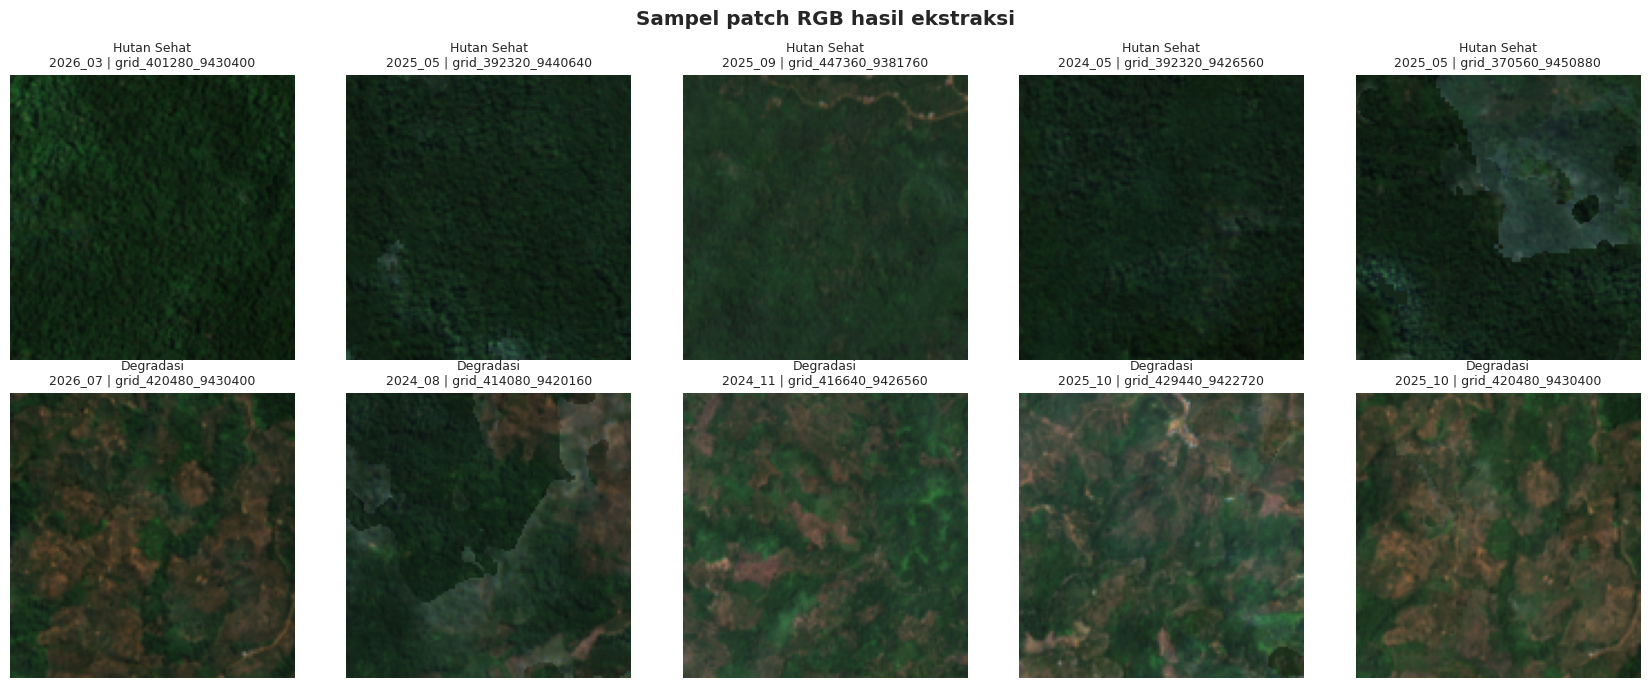

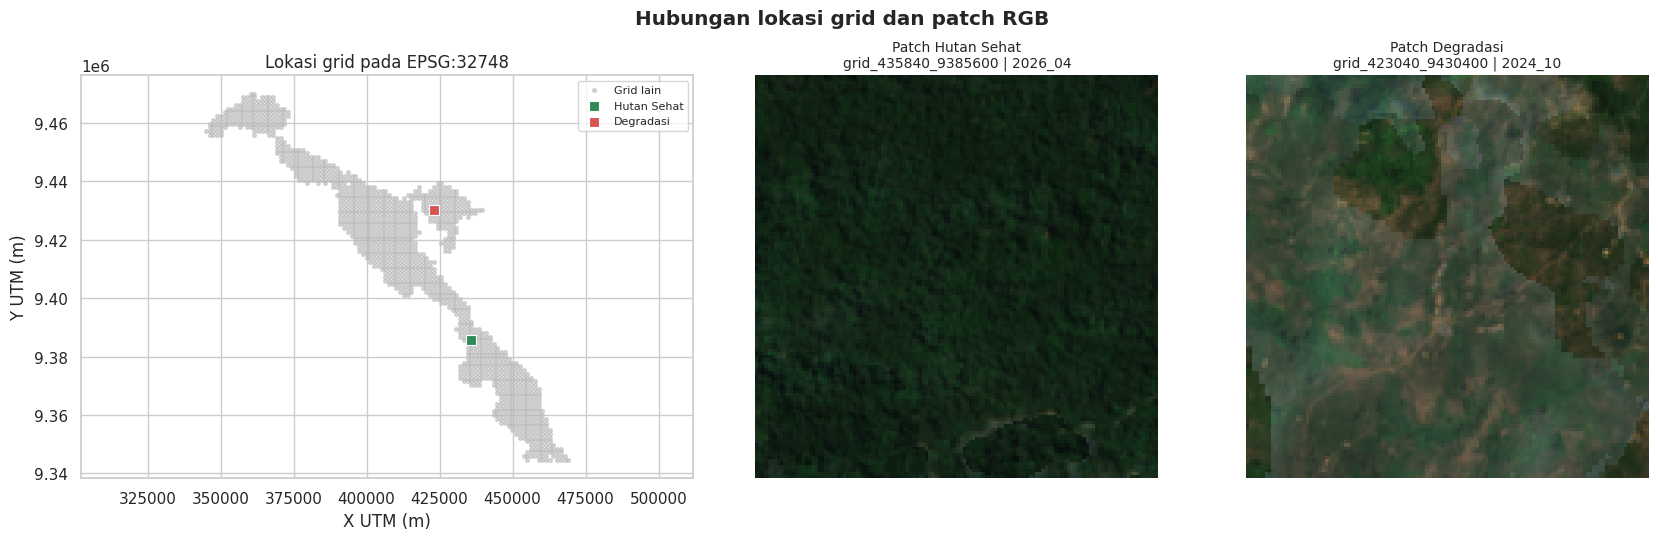

,grid_id,target_month,label_name,degraded_fraction,clear_fraction,mean_ndvi,x_utm,y_utm
0,grid_401280_9412480,2024_01,hutan_sehat,0.0000,0.8438,0.8057,401280,9412480
1,grid_432000_9374080,2024_01,hutan_sehat,0.0000,0.9003,0.8635,432000,9374080
2,grid_432000_9375360,2024_01,hutan_sehat,0.0000,1.0000,0.8742,432000,9375360
3,grid_425600_9424000,2024_01,degradasi,0.0499,0.8521,0.5540,425600,9424000
4,grid_426880_9424000,2024_01,degradasi,0.0421,0.8728,0.5490,426880,9424000
5,grid_415360_9427840,2024_02,degradasi,0.0222,0.9602,0.6597,415360,9427840


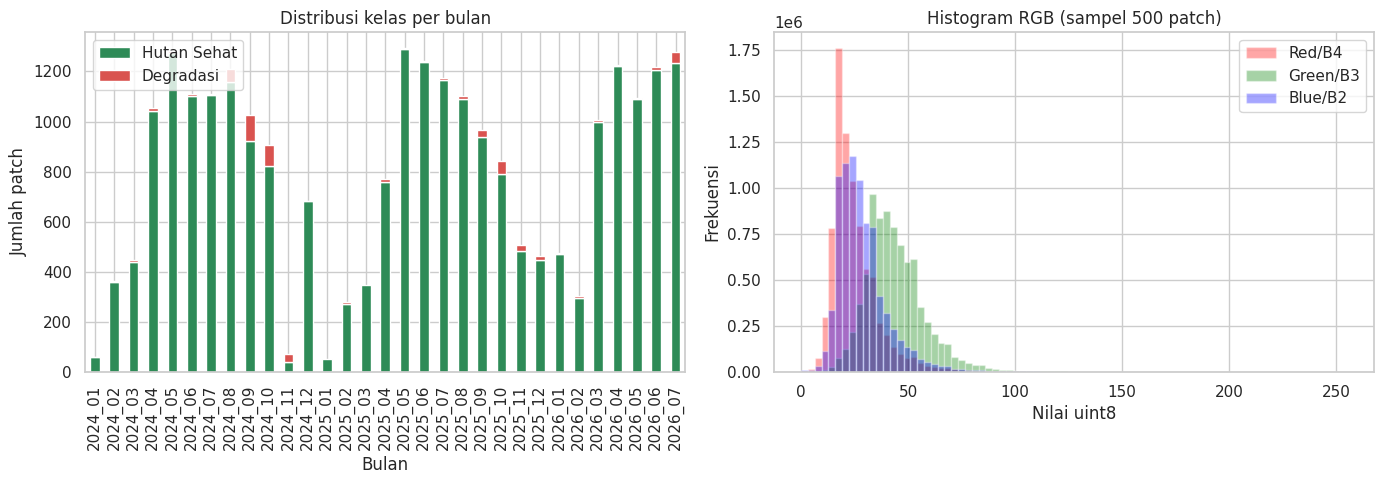

In [26]:
class_names = ["Hutan Sehat", "Degradasi"]
class_colors = {0: "#2e8b57", 1: "#d9534f"}
rng = np.random.default_rng(SEED)

# Tampilkan sampel acak setiap kelas; seed membuat pilihan dapat direproduksi.
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for label_value in (0, 1):
    candidates = np.flatnonzero(labels == label_value)
    chosen = rng.choice(candidates, size=min(5, len(candidates)), replace=False)
    for column, array_index in enumerate(chosen):
        axes[label_value, column].imshow(patches[array_index].transpose(1, 2, 0))
        row = extracted_metadata.iloc[array_index]
        axes[label_value, column].set_title(
            f"{class_names[label_value]}\n{row['target_month']} | {row['grid_id']}",
            fontsize=9,
        )
        axes[label_value, column].axis("off")

plt.suptitle("Sampel patch RGB hasil ekstraksi", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "contoh_patch_dataset.png", dpi=180, bbox_inches="tight")
plt.show()

# Hubungkan koordinat grid dengan patch yang benar-benar dibaca dari GeoTIFF.
selected_positions = {
    label_value: int(rng.choice(np.flatnonzero(labels == label_value)))
    for label_value in (0, 1)
}
grid_points = extracted_metadata.drop_duplicates("grid_id")

fig, axes = plt.subplots(
    1, 3, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1.35, 1, 1]}
)
axes[0].scatter(
    grid_points["x_utm"],
    grid_points["y_utm"],
    s=7,
    color="#b8b8b8",
    alpha=0.55,
    label="Grid lain",
)

for panel, label_value in enumerate((0, 1), start=1):
    array_index = selected_positions[label_value]
    row = extracted_metadata.iloc[array_index]
    x_utm = float(row["x_utm"])
    y_utm = float(row["y_utm"])
    color = class_colors[label_value]

    axes[0].add_patch(
        Rectangle(
            (x_utm - PATCH_HALF_M, y_utm - PATCH_HALF_M),
            2 * PATCH_HALF_M,
            2 * PATCH_HALF_M,
            fill=False,
            edgecolor=color,
            linewidth=2.0,
            zorder=3,
        )
    )
    axes[0].scatter(
        x_utm,
        y_utm,
        s=55,
        marker="s",
        color=color,
        edgecolor="white",
        linewidth=0.8,
        label=class_names[label_value],
        zorder=4,
    )

    axes[panel].imshow(patches[array_index].transpose(1, 2, 0))
    axes[panel].set_title(
        f"Patch {class_names[label_value]}\n"
        f"{row['grid_id']} | {row['target_month']}",
        fontsize=10,
    )
    axes[panel].axis("off")

axes[0].set_title("Lokasi grid pada EPSG:32748")
axes[0].set_xlabel("X UTM (m)")
axes[0].set_ylabel("Y UTM (m)")
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].legend(loc="best", fontsize=8)

plt.suptitle("Hubungan lokasi grid dan patch RGB", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grid_dan_patch_dataset.png", dpi=200, bbox_inches="tight")
plt.show()

# Cuplikan metadata untuk laporan: tiga baris per kelas dan hanya kolom utama.
metadata_preview_columns = [
    "grid_id",
    "target_month",
    "label_name",
    "degraded_fraction",
    "clear_fraction",
    "mean_ndvi",
    "x_utm",
    "y_utm",
]
metadata_preview = pd.concat(
    [
        extracted_metadata.loc[extracted_metadata["label"] == label_value].head(3)
        for label_value in (0, 1)
    ],
    ignore_index=True,
)[metadata_preview_columns]
metadata_preview.to_csv(OUTPUT_DIR / "metadata_preview.csv", index=False)
display(
    metadata_preview.style.format(
        {
            "degraded_fraction": "{:.4f}",
            "clear_fraction": "{:.4f}",
            "mean_ndvi": "{:.4f}",
            "x_utm": "{:.0f}",
            "y_utm": "{:.0f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.crosstab(extracted_metadata["target_month"], extracted_metadata["label"]).plot(
    kind="bar", stacked=True, ax=axes[0], color=[class_colors[0], class_colors[1]]
)
axes[0].set_title("Distribusi kelas per bulan")
axes[0].set_xlabel("Bulan")
axes[0].set_ylabel("Jumlah patch")
axes[0].legend(class_names)

hist_sample_size = min(500, len(patches))
hist_indices = rng.choice(len(patches), size=hist_sample_size, replace=False)
for band_index, (band_name, color) in enumerate(
    [("Red/B4", "red"), ("Green/B3", "green"), ("Blue/B2", "blue")]
):
    axes[1].hist(
        patches[hist_indices, band_index].ravel(),
        bins=80,
        alpha=0.35,
        label=band_name,
        color=color,
    )
axes[1].set_title(f"Histogram RGB (sampel {hist_sample_size} patch)")
axes[1].set_xlabel("Nilai uint8")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "statistik_dataset.png", dpi=180, bbox_inches="tight")
plt.show()


### 8. Dataset dan DataLoader

In [27]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class DegradationOnlyAugment:
    """Augmentasi geometrik hanya untuk virtual copy kelas degradasi."""

    def __init__(
        self,
        crop_probability=0.70,
        crop_min_area_scale=0.90,
        crop_min_fraction=0.03,
    ):
        if not 0 <= crop_probability <= 1:
            raise ValueError("crop_probability harus berada pada [0,1]")
        if not 0 < crop_min_area_scale <= 1:
            raise ValueError("crop_min_area_scale harus berada pada (0,1]")
        self.crop_probability = float(crop_probability)
        self.crop_min_area_scale = float(crop_min_area_scale)
        self.crop_min_fraction = float(crop_min_fraction)

    def __call__(
        self,
        image,
        label,
        degraded_fraction,
        return_params=False,
    ):
        params = {
            "applied": False,
            "crop_applied": False,
            "crop_area_scale": 1.0,
            "crop_top": 0,
            "crop_left": 0,
            "crop_side_px": int(image.shape[-1]),
            "rotation_degrees": 0,
            "horizontal_flip": False,
            "vertical_flip": False,
        }
        # Kelas sehat dan evaluasi tidak pernah masuk cabang ini.
        if int(label) != 1:
            return (image, params) if return_params else image

        augmented = image.clone()
        height, width = augmented.shape[-2:]

        crop_allowed = float(degraded_fraction) >= self.crop_min_fraction
        if crop_allowed and torch.rand(()) < self.crop_probability:
            area_scale = float(
                torch.empty(()).uniform_(
                    self.crop_min_area_scale, 1.0
                ).item()
            )
            side = int(round(min(height, width) * math.sqrt(area_scale)))
            side = max(2, min(side, height, width))
            max_top = height - side
            max_left = width - side
            top = int(
                torch.randint(0, max_top + 1, ()).item()
            ) if max_top else 0
            left = int(
                torch.randint(0, max_left + 1, ()).item()
            ) if max_left else 0
            cropped = augmented[
                :, top:top + side, left:left + side
            ].unsqueeze(0).float()
            augmented = (
                F.interpolate(
                    cropped,
                    size=(height, width),
                    mode="bilinear",
                    align_corners=False,
                    antialias=True,
                )
                .round()
                .clamp_(0, 255)
                .to(dtype=image.dtype)
                .squeeze(0)
            )
            params.update({
                "crop_applied": True,
                "crop_area_scale": area_scale,
                "crop_top": top,
                "crop_left": left,
                "crop_side_px": side,
            })

        rotation_quarters = int(torch.randint(0, 4, ()).item())
        if rotation_quarters:
            augmented = torch.rot90(
                augmented, k=rotation_quarters, dims=(-2, -1)
            )
            params["rotation_degrees"] = 90 * rotation_quarters

        if bool(torch.rand(()) < 0.5):
            augmented = torch.flip(augmented, dims=(-1,))
            params["horizontal_flip"] = True
        if bool(torch.rand(()) < 0.5):
            augmented = torch.flip(augmented, dims=(-2,))
            params["vertical_flip"] = True

        # Pastikan virtual copy tidak identik dengan citra asli.
        changed = (
            params["crop_applied"]
            or params["rotation_degrees"] != 0
            or params["horizontal_flip"]
            or params["vertical_flip"]
        )
        if not changed:
            augmented = torch.flip(augmented, dims=(-1,))
            params["horizontal_flip"] = True

        params["applied"] = True
        return (augmented, params) if return_params else augmented


train_transform = DegradationOnlyAugment(
    crop_probability=DEGRADATION_CROP_PROBABILITY,
    crop_min_area_scale=DEGRADATION_CROP_MIN_AREA_SCALE,
    crop_min_fraction=DEGRADATION_CROP_MIN_FRACTION,
)
eval_transform = None
degraded_fraction_array = (
    extracted_metadata["degraded_fraction"].to_numpy(dtype=np.float32)
)


class PatchDataset(Dataset):
    def __init__(
        self,
        patch_array,
        label_array,
        degraded_fraction_values,
        indices,
        transform=None,
        degradation_augmented_copies=0,
    ):
        self.patch_array = patch_array
        self.label_array = label_array
        self.degraded_fraction_values = degraded_fraction_values
        base_indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform

        augmented_indices = np.asarray([], dtype=np.int64)
        copies = int(degradation_augmented_copies)
        if copies > 0:
            degradation_indices = base_indices[
                label_array[base_indices] == 1
            ]
            augmented_indices = np.tile(
                degradation_indices, copies
            )

        self.indices = np.concatenate([
            base_indices,
            augmented_indices,
        ])
        self.is_augmented_copy = np.concatenate([
            np.zeros(len(base_indices), dtype=bool),
            np.ones(len(augmented_indices), dtype=bool),
        ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        array_index = int(self.indices[item])
        image = torch.from_numpy(
            np.asarray(self.patch_array[array_index]).copy()
        )
        label_value = int(self.label_array[array_index])
        if self.is_augmented_copy[item]:
            if self.transform is None:
                raise RuntimeError(
                    "Virtual augmented copy tidak memiliki transform."
                )
            image = self.transform(
                image,
                label=label_value,
                degraded_fraction=float(
                    self.degraded_fraction_values[array_index]
                ),
            )
        label = torch.tensor(label_value, dtype=torch.long)
        return image, label


split_indices = {
    split_name: np.flatnonzero(
        extracted_metadata["spatial_split"].to_numpy()
        == split_name
    )
    for split_name in ("train", "val", "test")
}

train_dataset = PatchDataset(
    patches,
    labels,
    degraded_fraction_array,
    split_indices["train"],
    transform=train_transform,
    degradation_augmented_copies=DEGRADATION_AUGMENTED_COPIES,
)
val_dataset = PatchDataset(
    patches,
    labels,
    degraded_fraction_array,
    split_indices["val"],
    transform=eval_transform,
    degradation_augmented_copies=0,
)
test_dataset = PatchDataset(
    patches,
    labels,
    degraded_fraction_array,
    split_indices["test"],
    transform=eval_transform,
    degradation_augmented_copies=0,
)



def seed_worker(worker_id):
    torch.set_num_threads(1)
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
if NUM_WORKERS > 0:
    loader_kwargs.update(
        persistent_workers=True,
        worker_init_fn=seed_worker,
        prefetch_factor=4,
    )


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

split_rows = []
for split_name, indices in split_indices.items():
    split_labels = labels[indices]
    split_rows.append({
        "Split": split_name,
        "Jumlah patch": len(indices),
        "Hutan sehat": int((split_labels == 0).sum()),
        "Degradasi": int((split_labels == 1).sum()),
    })

effective_train_labels = labels[train_dataset.indices]
effective_healthy = int((effective_train_labels == 0).sum())
effective_degradation = int((effective_train_labels == 1).sum())
split_summary = pd.DataFrame(split_rows)
split_summary.loc[len(split_summary)] = {
    "Split": "train efektif",
    "Jumlah patch": len(train_dataset),
    "Hutan sehat": effective_healthy,
    "Degradasi": effective_degradation,
}
display(split_summary)


,Split,Jumlah patch,Hutan sehat,Degradasi
0,train,17402,17012,390
1,val,3888,3797,91
2,test,3659,3581,78
3,train efektif,17792,17012,780


### 9. Visual Augmentasi Pada Label Degradasi

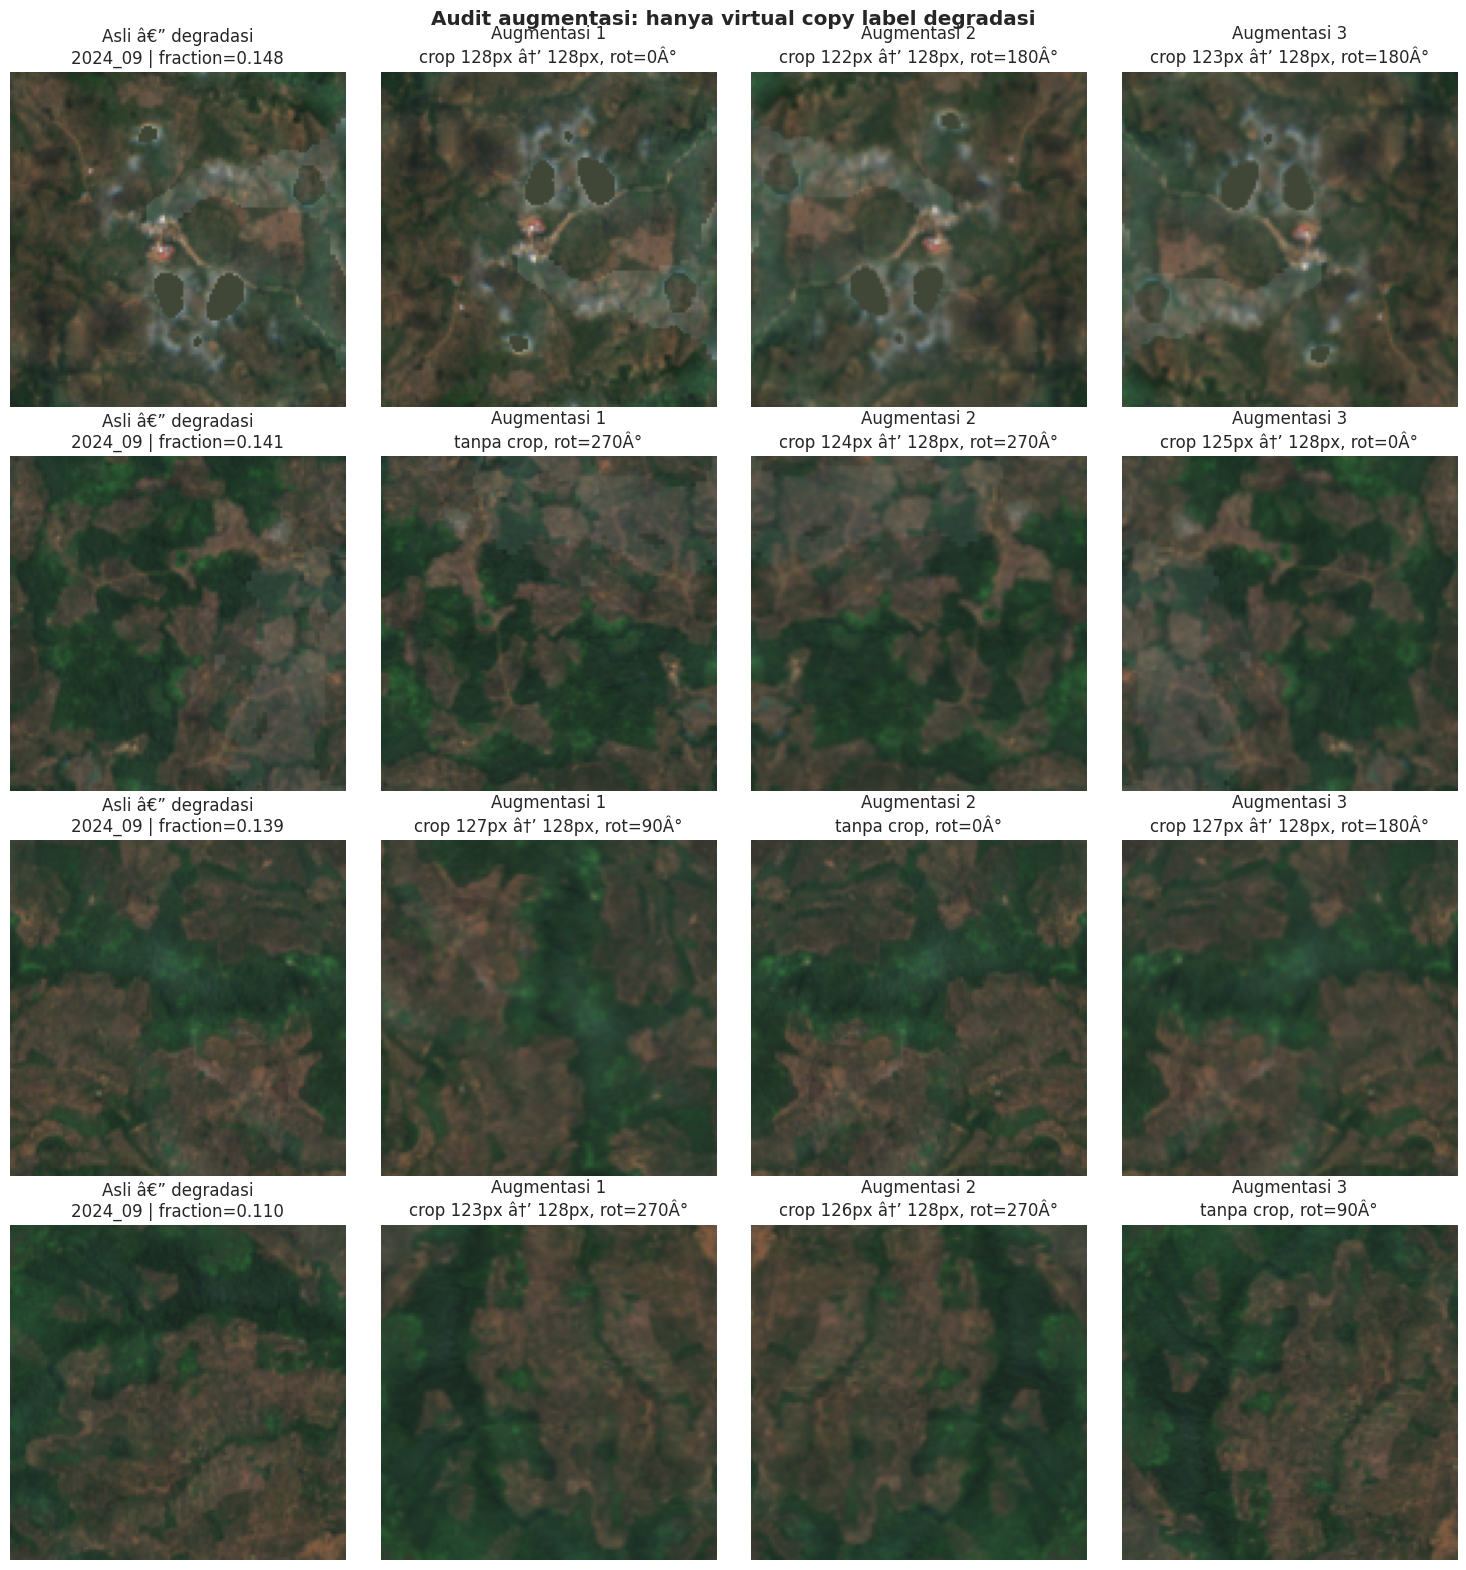

,grid_id,target_month,degraded_fraction,variant,applied,crop_applied,crop_area_scale,crop_top,crop_left,crop_side_px,rotation_degrees,horizontal_flip,vertical_flip
0,grid_429440_9418880,2024_09,0.147878,1,True,True,0.999778,0,0,128,0,False,True
1,grid_429440_9418880,2024_09,0.147878,2,True,True,0.909166,6,3,122,180,False,True
2,grid_429440_9418880,2024_09,0.147878,3,True,True,0.916157,5,2,123,180,False,False
3,grid_412800_9427840,2024_09,0.140954,1,True,False,1.000000,0,0,128,270,True,True
4,grid_412800_9427840,2024_09,0.140954,2,True,True,0.939275,4,0,124,270,False,True
5,grid_412800_9427840,2024_09,0.140954,3,True,True,0.953708,3,1,125,0,True,False
6,grid_415360_9425280,2024_09,0.138630,1,True,True,0.981217,0,1,127,90,True,False
7,grid_415360_9425280,2024_09,0.138630,2,True,False,1.000000,0,0,128,0,True,False
8,grid_415360_9425280,2024_09,0.138630,3,True,True,0.989363,1,1,127,180,False,True
9,grid_414080_9425280,2024_09,0.110167,1,True,True,0.928654,3,2,123,270,True,True


In [28]:
train_degradation_indices = split_indices["train"][
    labels[split_indices["train"]] == 1
]
audit_source_indices = train_degradation_indices[
    np.argsort(
        degraded_fraction_array[train_degradation_indices]
    )[::-1][:4]
]

# Simpan dan pulihkan RNG agar visualisasi tidak mengubah urutan random training.
cpu_rng_state = torch.random.get_rng_state()
torch.manual_seed(SEED + 9001)
augmentation_audit_rows = []

fig, axes = plt.subplots(
    len(audit_source_indices), 4,
    figsize=(15, 4 * len(audit_source_indices)),
)
if len(audit_source_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, array_index in enumerate(audit_source_indices):
    original = torch.from_numpy(
        np.asarray(patches[array_index]).copy()
    )
    metadata_row = extracted_metadata.iloc[array_index]
    degraded_fraction = float(
        degraded_fraction_array[array_index]
    )

    axes[row_index, 0].imshow(
        original.permute(1, 2, 0).numpy()
    )
    axes[row_index, 0].set_title(
        f"Asli â€” degradasi\n"
        f"{metadata_row['target_month']} | "
        f"fraction={degraded_fraction:.3f}"
    )
    axes[row_index, 0].axis("off")

    for variant in range(1, 4):
        augmented, params = train_transform(
            original,
            label=1,
            degraded_fraction=degraded_fraction,
            return_params=True,
        )
        axes[row_index, variant].imshow(
            augmented.permute(1, 2, 0).numpy()
        )
        crop_text = (
            f"crop {params['crop_side_px']}px â†’ 128px"
            if params["crop_applied"]
            else "tanpa crop"
        )
        axes[row_index, variant].set_title(
            f"Augmentasi {variant}\n"
            f"{crop_text}, rot={params['rotation_degrees']}Â°"
        )
        axes[row_index, variant].axis("off")

        augmentation_audit_rows.append({
            "grid_id": metadata_row["grid_id"],
            "target_month": metadata_row["target_month"],
            "degraded_fraction": degraded_fraction,
            "variant": variant,
            **params,
        })

# Unit check: transform yang sama tidak boleh mengubah kelas sehat.
healthy_index = int(
    split_indices["train"][
        np.flatnonzero(
            labels[split_indices["train"]] == 0
        )[0]
    ]
)
healthy_original = torch.from_numpy(
    np.asarray(patches[healthy_index]).copy()
)
healthy_after, healthy_params = train_transform(
    healthy_original,
    label=0,
    degraded_fraction=float(
        degraded_fraction_array[healthy_index]
    ),
    return_params=True,
)
assert torch.equal(healthy_original, healthy_after)
assert healthy_params["applied"] is False

torch.random.set_rng_state(cpu_rng_state)

plt.suptitle(
    "Audit augmentasi: hanya virtual copy label degradasi",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "degradation_augmentation_examples.png",
    dpi=190,
    bbox_inches="tight",
)
plt.show()

augmentation_audit_table = pd.DataFrame(
    augmentation_audit_rows
)
augmentation_audit_table.to_csv(
    OUTPUT_DIR / "degradation_augmentation_audit.csv",
    index=False,
)
display(augmentation_audit_table.head(12))


## Bagian 2 — Pengembangan dan Pelatihan Model


### 10. EfficientNet-B4 Pretrained dan Focal Loss

In [29]:
class ForestDegradationModel(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4):
        super().__init__()
        weights = models.EfficientNet_B4_Weights.DEFAULT
        self.backbone = models.efficientnet_b4(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, num_classes),
        )
        self.register_buffer(
            "image_mean",
            torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(1, 3, 1, 1),
        )
        self.register_buffer(
            "image_std",
            torch.tensor(IMAGENET_STD, dtype=torch.float32).view(1, 3, 1, 1),
        )

    def forward(self, x):
        # Ubah uint8 ke [0,1], resize ke 380, lalu normalisasi sesuai bobot ImageNet.
        x = x.to(dtype=torch.float32).div_(255.0)
        # Augmentasi dilakukan di PatchDataset hanya pada virtual copy degradasi.
        # Validation, test, dan seluruh patch sehat melewati forward tanpa augmentasi.
        x = F.interpolate(
            x,
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode="bilinear",
            align_corners=False,
            antialias=False,
        )
        x = (x - self.image_mean) / self.image_std
        x = x.contiguous(memory_format=torch.channels_last)
        return self.backbone(x)

    def freeze_backbone(self):
        for parameter in self.backbone.features.parameters():
            parameter.requires_grad = False
        for parameter in self.backbone.classifier.parameters():
            parameter.requires_grad = True

    def unfreeze_backbone(self, unfreeze_from=6):
        for parameter in self.backbone.features.parameters():
            parameter.requires_grad = False
        for block_index in range(unfreeze_from, len(self.backbone.features)):
            for parameter in self.backbone.features[block_index].parameters():
                parameter.requires_grad = True
        for parameter in self.backbone.classifier.parameters():
            parameter.requires_grad = True


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = float(gamma)
        self.reduction = reduction
        if alpha is None:
            self.alpha = None
        else:
            alpha_tensor = torch.as_tensor(alpha, dtype=torch.float32)
            if alpha_tensor.numel() != NUM_CLASSES:
                raise ValueError(f"alpha harus berisi {NUM_CLASSES} nilai")
            self.register_buffer("alpha", alpha_tensor)

    def forward(self, logits, targets):
        # pt dihitung dari CE tanpa class weight; alpha diterapkan setelah modulating factor.
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        loss = (1.0 - pt).pow(self.gamma) * ce_loss
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


# Unit check: gamma=0 dan tanpa alpha harus identik dengan Cross Entropy.
_test_logits = torch.tensor([[1.2, -0.2], [0.1, 0.9]], dtype=torch.float32)
_test_targets = torch.tensor([0, 1], dtype=torch.long)
assert torch.allclose(
    FocalLoss(gamma=0.0)(_test_logits, _test_targets),
    F.cross_entropy(_test_logits, _test_targets),
    atol=1e-7,
)



def keep_frozen_blocks_in_eval_mode(model):
    """Cegah running statistics BatchNorm berubah pada blok yang dibekukan."""
    core = model
    for block in core.backbone.features:
        if not any(parameter.requires_grad for parameter in block.parameters()):
            block.eval()


def stabilize_backbone_batchnorm(model):
    """Bekukan running mean/variance BN tanpa mematikan gradien affine-nya.

    Gradient accumulation tidak memperbesar physical batch yang dilihat oleh
    BatchNorm. Dengan physical batch 16, statistik pretrained lebih stabil jika
    tidak diperbarui pada setiap minibatch yang sangat timpang.
    """
    if not FREEZE_BACKBONE_BATCHNORM_STATS:
        return
    core = model
    for module in core.backbone.features.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()


model = ForestDegradationModel(NUM_CLASSES, DROPOUT_RATE).to(
    DEVICE, memory_format=torch.channels_last
)
criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA).to(DEVICE)

model_summary = pd.DataFrame([{
    "Arsitektur": "EfficientNet-B4",
    "Bobot awal": "ImageNet-1K",
    "Jumlah kelas": NUM_CLASSES,
    "Total parameter": sum(p.numel() for p in model.parameters()),
    "Dropout": DROPOUT_RATE,
    "Focal gamma": FOCAL_GAMMA,
    "Focal alpha": str(FOCAL_ALPHA),
}])
display(model_summary)


,Arsitektur,Bobot awal,Jumlah kelas,Total parameter,Dropout,Focal gamma,Focal alpha
0,EfficientNet-B4,ImageNet-1K,2,17552202,0.4,2.0,None


### 11. Fungsi Training, Validasi, dan Early Stopping


In [30]:
def amp_context():
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


try:
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def classification_metrics(y_true, y_pred, y_prob):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    specificity = tn / max(tn + fp, 1)

    precision_degradation = precision_score(
        y_true, y_pred, pos_label=1, zero_division=0
    )
    recall_degradation = recall_score(
        y_true, y_pred, pos_label=1, zero_division=0
    )
    f1_degradation = f1_score(
        y_true, y_pred, pos_label=1, zero_division=0
    )
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_degradation,
        "recall": recall_degradation,
        "f1": f1_degradation,
        "precision_degradation": precision_degradation,
        "recall_degradation": recall_degradation,
        "f1_degradation": f1_degradation,
        "precision_healthy": precision_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),
        "recall_healthy": recall_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),
        "f1_healthy": f1_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),
        "specificity": specificity,
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "positive_prevalence": float(np.mean(y_true == 1)),
        "pr_auc": (
            average_precision_score(y_true, y_prob)
            if len(np.unique(y_true)) == 2 else float("nan")
        ),
        "roc_auc": (
            roc_auc_score(y_true, y_prob)
            if len(np.unique(y_true)) == 2 else float("nan")
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
    return metrics


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    keep_frozen_blocks_in_eval_mode(model)
    stabilize_backbone_batchnorm(model)
    optimizer.zero_grad(set_to_none=True)
    running_loss = torch.zeros((), device=device)
    correct = torch.zeros((), dtype=torch.long, device=device)
    total = 0

    progress = tqdm(loader, desc="Train", leave=False)
    for step, (images, targets) in enumerate(progress):
        # Transfer tetap uint8 128 x 128; preprocessing dilakukan per-replika
        # di ForestDegradationModel.forward().
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with amp_context():
            logits = model(images)
            raw_loss = criterion(logits, targets)
            loss = raw_loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        should_step = (
            (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader)
        )
        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += raw_loss.detach() * images.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == targets).sum()
        total += targets.size(0)
        # .item() menyinkronkan CPU-GPU; cukup per 25 batch untuk progress UI.
        if (step + 1) % 25 == 0 or (step + 1) == len(loader):
            progress.set_postfix(loss=f"{(running_loss / max(total, 1)).item():.4f}")

    return {
        "loss": (running_loss / total).item(),
        "accuracy": (correct.float() / total).item(),
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = torch.zeros((), device=device)
    all_targets = []
    all_predictions = []
    all_probabilities = []

    for images, targets in tqdm(loader, desc="Evaluate", leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with amp_context():
            logits = model(images)
            loss = criterion(logits, targets)

        probabilities = torch.softmax(logits.float(), dim=1)[:, 1]
        predictions = logits.argmax(dim=1)
        running_loss += loss.detach() * images.size(0)
        all_targets.append(targets.detach())
        all_predictions.append(predictions.detach())
        all_probabilities.append(probabilities.detach())

    y_true = torch.cat(all_targets).cpu().numpy().astype(np.int64, copy=False)
    y_pred = torch.cat(all_predictions).cpu().numpy().astype(np.int64, copy=False)
    y_prob = torch.cat(all_probabilities).cpu().numpy().astype(np.float32, copy=False)
    metrics = classification_metrics(y_true, y_pred, y_prob)
    metrics["loss"] = (running_loss / len(y_true)).item()
    metrics["targets"] = y_true
    metrics["predictions"] = y_pred
    metrics["probabilities"] = y_prob
    return metrics


class EarlyStopping:
    """Checkpoint dan early stopping berdasarkan metrik validation utama."""

    def __init__(
        self,
        patience,
        checkpoint_path,
        monitor_name="pr_auc",
        mode="max",
        min_delta=0.0,
        initial_best_value=None,
    ):
        if mode not in {"min", "max"}:
            raise ValueError("mode EarlyStopping harus 'min' atau 'max'")
        self.patience = int(patience)
        self.checkpoint_path = Path(checkpoint_path)
        self.monitor_name = str(monitor_name)
        self.mode = mode
        self.min_delta = float(min_delta)
        default_best = math.inf if mode == "min" else -math.inf
        self.best_value = (
            default_best
            if initial_best_value is None
            else float(initial_best_value)
        )
        self.counter = 0
        self.last_improved = False

    def _is_improved(self, value):
        if self.mode == "min":
            return value < self.best_value - self.min_delta
        return value > self.best_value + self.min_delta

    def step(self, validation_result, model, epoch):
        monitor_value = float(validation_result[self.monitor_name])
        improved = self._is_improved(monitor_value)
        self.last_improved = improved
        if improved:
            self.best_value = monitor_value
            self.counter = 0
            saved_metrics = {
                name: float(validation_result[name])
                for name in (
                    "loss",
                    "accuracy",
                    "balanced_accuracy",
                    "precision",
                    "recall",
                    "f1",
                    "pr_auc",
                    "roc_auc",
                )
            }
            torch.save(
                {
                    "epoch": int(epoch),
                    "val_loss": float(validation_result["loss"]),
                    "monitor_name": self.monitor_name,
                    "monitor_mode": self.mode,
                    "monitor_value": monitor_value,
                    "val_metrics": saved_metrics,
                    "model_state_dict": model.state_dict(),
                },
                self.checkpoint_path,
            )
        else:
            self.counter += 1
        return self.counter >= self.patience


def optimizer_learning_rates(optimizer):
    return {
        group.get("group_name", f"group_{index}"): float(group["lr"])
        for index, group in enumerate(optimizer.param_groups)
    }


def train_phase(
    phase_name,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs,
    checkpoint_path,
    initial_best_value=None,
):
    stopper = EarlyStopping(
        EARLY_STOPPING_PATIENCE,
        checkpoint_path,
        monitor_name=CHECKPOINT_MONITOR,
        mode=CHECKPOINT_MODE,
        min_delta=CHECKPOINT_MIN_DELTA,
        initial_best_value=initial_best_value,
    )
    history = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()
        used_learning_rates = optimizer_learning_rates(optimizer)
        train_result = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_result = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step(val_result["loss"])
        next_learning_rates = optimizer_learning_rates(optimizer)

        record = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_result["loss"],
            "train_accuracy": train_result["accuracy"],
            "val_loss": val_result["loss"],
            "val_accuracy": val_result["accuracy"],
            "val_balanced_accuracy": val_result["balanced_accuracy"],
            "val_precision": val_result["precision"],
            "val_recall": val_result["recall"],
            "val_f1": val_result["f1"],
            "val_pr_auc": val_result["pr_auc"],
            "learning_rate": max(used_learning_rates.values()),
            "minimum_learning_rate": min(used_learning_rates.values()),
            "seconds": time.time() - start_time,
        }
        for group_name, learning_rate in used_learning_rates.items():
            record[f"lr_{group_name}"] = learning_rate
        for group_name, learning_rate in next_learning_rates.items():
            record[f"next_lr_{group_name}"] = learning_rate
        history.append(record)

        lr_text = ", ".join(
            f"{name}={value:.1e}"
            for name, value in used_learning_rates.items()
        )
        next_lr_text = ""
        if next_learning_rates != used_learning_rates:
            next_lr_text = " | next lr=" + ", ".join(
                f"{name}={value:.1e}"
                for name, value in next_learning_rates.items()
            )
        print(
            f"{phase_name} | epoch {epoch:02d}/{epochs} | "
            f"train loss={record['train_loss']:.4f} | "
            f"val loss={record['val_loss']:.4f} | "
            f"val F1={record['val_f1']:.4f} | "
            f"val PR-AUC={record['val_pr_auc']:.4f} | "
            f"lr={lr_text}{next_lr_text}"
        )

        should_stop = stopper.step(val_result, model, epoch)
        record["checkpoint_saved"] = bool(stopper.last_improved)
        record["checkpoint_monitor"] = CHECKPOINT_MONITOR
        record["checkpoint_monitor_value"] = float(
            val_result[CHECKPOINT_MONITOR]
        )
        if should_stop:
            print(
                f"Early stopping pada {phase_name}, epoch {epoch}; "
                f"best val {CHECKPOINT_MONITOR}={stopper.best_value:.4f}"
            )
            break

    return pd.DataFrame(history)


### 12. Fase 1 — Feature Extraction

In [31]:
model.freeze_backbone()
trainable_phase_1 = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
print(f"Parameter trainable fase 1: {trainable_phase_1:,}")

optimizer_phase_1 = optim.AdamW(
    [
        {
            "params": [
                parameter
                for parameter in model.parameters()
                if parameter.requires_grad
            ],
            "lr": LR_PHASE_1,
            "group_name": "classifier",
        }
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler_phase_1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase_1,
    mode="min",
    factor=0.5,
    patience=LR_SCHEDULER_PATIENCE,
    threshold=1e-4,
    threshold_mode="abs",
    min_lr=1e-5,
)

phase_1_path = OUTPUT_DIR / "best_phase_1.pth"
history_phase_1 = train_phase(
    "phase_1",
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_phase_1,
    scheduler_phase_1,
    EPOCHS_PHASE_1,
    phase_1_path,
)


Parameter trainable fase 1: 3,586


Train:   0%|          | 0/1112 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/122 [00:00<?, ?it/s]

phase_1 | epoch 01/3 | train loss=0.0391 | val loss=0.0199 | val F1=0.0000 | val PR-AUC=0.4844 | lr=classifier=1.0e-04


Train:   0%|          | 0/1112 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/122 [00:00<?, ?it/s]

phase_1 | epoch 02/3 | train loss=0.0236 | val loss=0.0162 | val F1=0.3273 | val PR-AUC=0.6373 | lr=classifier=1.0e-04


Train:   0%|          | 0/1112 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/122 [00:00<?, ?it/s]

phase_1 | epoch 03/3 | train loss=0.0191 | val loss=0.0140 | val F1=0.5000 | val PR-AUC=0.7161 | lr=classifier=1.0e-04


### 13. Fase 2 — Fine-Tuning Konservatif Sebagian Backbone

In [32]:
phase_1_checkpoint = torch.load(phase_1_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(phase_1_checkpoint["model_state_dict"])
model.unfreeze_backbone(UNFREEZE_FROM)

trainable_phase_2 = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
print(f"Parameter trainable fase 2: {trainable_phase_2:,}")

backbone_phase_2_parameters = [
    parameter
    for parameter in model.backbone.features.parameters()
    if parameter.requires_grad
]
classifier_phase_2_parameters = [
    parameter
    for parameter in model.backbone.classifier.parameters()
    if parameter.requires_grad
]
backbone_phase_2_count = sum(
    parameter.numel() for parameter in backbone_phase_2_parameters
)
classifier_phase_2_count = sum(
    parameter.numel() for parameter in classifier_phase_2_parameters
)
assert backbone_phase_2_count + classifier_phase_2_count == trainable_phase_2
print(
    "Kelompok optimizer fase 2: "
    f"backbone={backbone_phase_2_count:,} @ {LR_PHASE_2_BACKBONE:.1e}; "
    f"classifier={classifier_phase_2_count:,} @ {LR_PHASE_2_CLASSIFIER:.1e}"
)

optimizer_phase_2 = optim.AdamW(
    [
        {
            "params": backbone_phase_2_parameters,
            "lr": LR_PHASE_2_BACKBONE,
            "group_name": "backbone",
        },
        {
            "params": classifier_phase_2_parameters,
            "lr": LR_PHASE_2_CLASSIFIER,
            "group_name": "classifier",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler_phase_2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase_2,
    mode="min",
    factor=0.5,
    patience=LR_SCHEDULER_PATIENCE,
    threshold=1e-4,
    threshold_mode="abs",
    min_lr=[1e-6, 1e-5],
)

best_model_path = OUTPUT_DIR / "best_model.pth"
# Jadikan checkpoint fase 1 sebagai global best awal. Fase 2 hanya menimpanya
# apabila validation PR-AUC benar-benar lebih baik. Validation loss tetap
# dipakai scheduler karena lebih halus untuk keputusan penurunan learning rate.
torch.save(phase_1_checkpoint, best_model_path)
history_phase_2 = train_phase(
    "phase_2",
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_phase_2,
    scheduler_phase_2,
    EPOCHS_PHASE_2,
    best_model_path,
    initial_best_value=phase_1_checkpoint["monitor_value"],
)

history = pd.concat([history_phase_1, history_phase_2], ignore_index=True)
history["global_epoch"] = np.arange(1, len(history) + 1)
saved_checkpoint_rows = history.loc[history["checkpoint_saved"].fillna(False)]
if saved_checkpoint_rows.empty:
    raise RuntimeError("Tidak ada checkpoint validation yang tersimpan")
selected_history_index = saved_checkpoint_rows.index[-1]
selected_global_epoch = int(
    history.loc[selected_history_index, "global_epoch"]
)
history["selected_final_checkpoint"] = False
history.loc[selected_history_index, "selected_final_checkpoint"] = True
history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
selected_history_row = history.loc[selected_history_index]
print(
    "Checkpoint final dipilih hanya dari validation: "
    f"{selected_history_row['phase']} epoch "
    f"{int(selected_history_row['epoch'])} "
    f"(global epoch {selected_global_epoch}), "
    f"PR-AUC={selected_history_row['val_pr_auc']:.4f}, "
    f"F1={selected_history_row['val_f1']:.4f}, "
    f"loss={selected_history_row['val_loss']:.4f}."
)


Parameter trainable fase 2: 13,916,218
Kelompok optimizer fase 2: backbone=13,912,632 @ 1.0e-05; classifier=3,586 @ 1.0e-04


Train:   0%|          | 0/1112 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/122 [00:00<?, ?it/s]

phase_2 | epoch 01/10 | train loss=0.0124 | val loss=0.0078 | val F1=0.8023 | val PR-AUC=0.8712 | lr=backbone=1.0e-05, classifier=1.0e-04


Train:   0%|          | 0/1112 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/122 [00:00<?, ?it/s]

phase_2 | epoch 09/10 | train loss=0.0018 | val loss=0.0073 | val F1=0.8313 | val PR-AUC=0.9186 | lr=backbone=5.0e-06, classifier=5.0e-05 | next lr=backbone=2.5e-06, classifier=2.5e-05


Train:   0%|          | 0/1112 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/122 [00:00<?, ?it/s]

phase_2 | epoch 10/10 | train loss=0.0017 | val loss=0.0069 | val F1=0.8471 | val PR-AUC=0.9186 | lr=backbone=2.5e-06, classifier=2.5e-05
Checkpoint final dipilih hanya dari validation: phase_2 epoch 7 (global epoch 10), PR-AUC=0.9188, F1=0.8421, loss=0.0064.


### 14. Kurva Pembelajaran

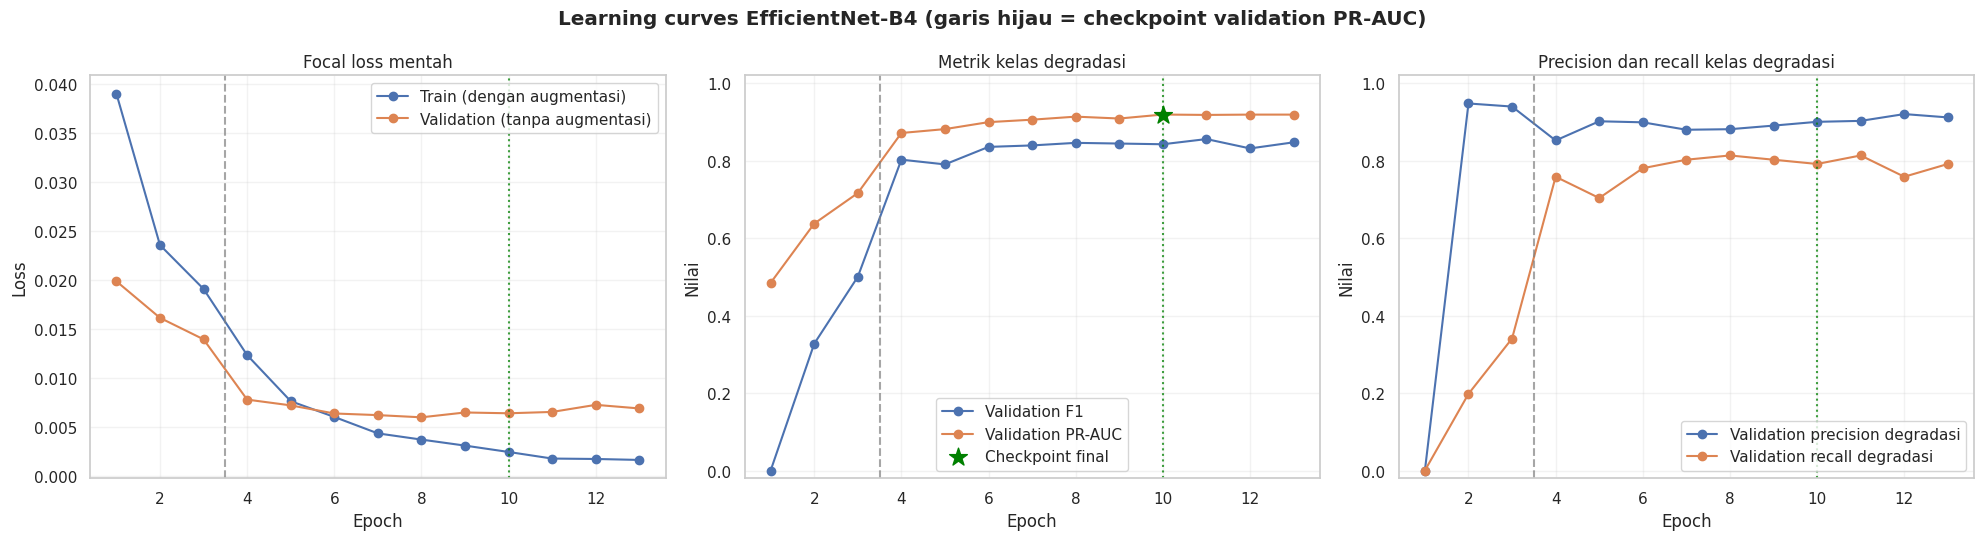

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Kurva loss digunakan untuk menilai konvergensi dan selisih train-validation.
axes[0].plot(
    history["global_epoch"],
    history["train_loss"],
    marker="o",
    label="Train (dengan augmentasi)",
)
axes[0].plot(
    history["global_epoch"],
    history["val_loss"],
    marker="o",
    label="Validation (tanpa augmentasi)",
)
axes[0].set_title("Focal loss mentah")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# PR-AUC dan F1 validation lebih informatif untuk kelas degradasi yang langka.
axes[1].plot(
    history["global_epoch"],
    history["val_f1"],
    marker="o",
    label="Validation F1",
)
axes[1].plot(
    history["global_epoch"],
    history["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC",
)
axes[1].scatter(
    [selected_global_epoch],
    [history.loc[selected_history_index, "val_pr_auc"]],
    marker="*",
    s=180,
    color="green",
    zorder=5,
    label="Checkpoint final",
)
axes[1].set_title("Metrik kelas degradasi")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Nilai")
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()

# Precision dan recall memperlihatkan keseimbangan kesalahan kelas degradasi.
axes[2].plot(
    history["global_epoch"],
    history["val_precision"],
    marker="o",
    label="Validation precision degradasi",
)
axes[2].plot(
    history["global_epoch"],
    history["val_recall"],
    marker="o",
    label="Validation recall degradasi",
)
axes[2].set_title("Precision dan recall kelas degradasi")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Nilai")
axes[2].set_ylim(-0.02, 1.02)
axes[2].legend()

phase_boundary = len(history_phase_1) + 0.5
for axis in axes:
    axis.axvline(phase_boundary, color="gray", linestyle="--", alpha=0.7)
    axis.axvline(
        selected_global_epoch,
        color="green",
        linestyle=":",
        alpha=0.75,
    )
    axis.grid(alpha=0.25)

plt.suptitle(
    "Learning curves EfficientNet-B4 (garis hijau = checkpoint validation PR-AUC)",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()


## Bagian 3 — Evaluasi dan Analisis Kinerja Model


### 15. Evaluasi Final pada Test Set

Evaluate:   0%|          | 0/122 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/115 [00:00<?, ?it/s]

Ambang keputusan dari validation set: 0.444414 | F1=0.8588 | precision=0.8837 | recall=0.8352
Hasil evaluasi NATURAL test set:
loss                    : 0.003419
accuracy                : 0.996174
balanced_accuracy       : 0.954151
macro_f1                : 0.954151
weighted_f1             : 0.996174
mcc                     : 0.908302
pr_auc                  : 0.965468
roc_auc                 : 0.998421
positive_prevalence     : 0.021317
tn                      : 3574.000000
fp                      : 7.000000
fn                      : 7.000000
tp                      : 71.000000
precision_hutan_sehat   : 0.998045
recall_hutan_sehat      : 0.998045
f1_hutan_sehat          : 0.998045
precision_degradasi     : 0.910256
recall_degradasi        : 0.910256
f1_degradasi            : 0.910256
decision_threshold      : 0.444414
Metrik setiap kelas pada NATURAL test set:


,kelas,precision,recall,f1_score,support
0,Hutan Sehat,0.9980,0.9980,0.9980,3581
1,Degradasi,0.9103,0.9103,0.9103,78


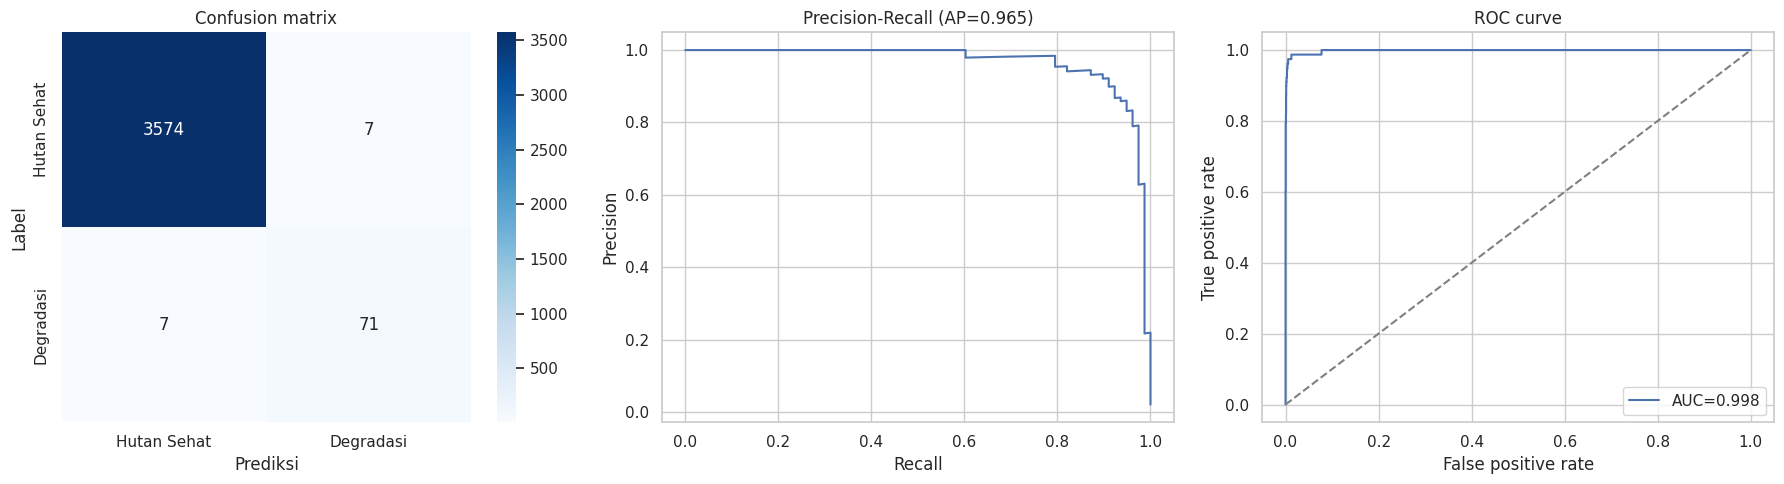

In [41]:
best_checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()


def select_validation_f1_threshold(targets, probabilities):
    precision_values, recall_values, thresholds = precision_recall_curve(
        targets,
        probabilities,
    )
    if len(thresholds) == 0:
        return 0.5
    f1_values = (
        2
        * precision_values[:-1]
        * recall_values[:-1]
        / np.clip(
            precision_values[:-1] + recall_values[:-1],
            1e-12,
            None,
        )
    )
    return float(thresholds[int(np.nanargmax(f1_values))])


validation_selection_result = evaluate(
    model,
    val_loader,
    criterion,
    DEVICE,
)
decision_threshold = select_validation_f1_threshold(
    validation_selection_result["targets"],
    validation_selection_result["probabilities"],
)
validation_selected_predictions = (
    validation_selection_result["probabilities"] >= decision_threshold
).astype(np.int64)
validation_selected_metrics = classification_metrics(
    validation_selection_result["targets"],
    validation_selected_predictions,
    validation_selection_result["probabilities"],
)

test_result = evaluate(model, test_loader, criterion, DEVICE)
test_result["predictions"] = (
    test_result["probabilities"] >= decision_threshold
).astype(np.int64)
test_result.update(
    classification_metrics(
        test_result["targets"],
        test_result["predictions"],
        test_result["probabilities"],
    )
)
metric_names = [
    "loss",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "mcc",
    "pr_auc",
    "roc_auc",
    "positive_prevalence",
    "tn",
    "fp",
    "fn",
    "tp",
]

report = classification_report(
    test_result["targets"],
    test_result["predictions"],
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_frame = pd.DataFrame(report).transpose()
report_frame.to_csv(OUTPUT_DIR / "classification_report.csv")

# Metrik kedua kelas pada natural test set tanpa menyebut recall sebagai accuracy kelas.
natural_class_metrics = pd.DataFrame({
    "kelas": class_names,
    "precision": [
        report[class_names[0]]["precision"],
        report[class_names[1]]["precision"],
    ],
    "recall": [
        report[class_names[0]]["recall"],
        report[class_names[1]]["recall"],
    ],
    "f1_score": [
        report[class_names[0]]["f1-score"],
        report[class_names[1]]["f1-score"],
    ],
    "support": [
        int(report[class_names[0]]["support"]),
        int(report[class_names[1]]["support"]),
    ],
})
natural_class_metrics.to_csv(
    OUTPUT_DIR / "natural_test_metrics_per_class.csv", index=False
)

class_metric_values = {
    "precision_hutan_sehat": float(report[class_names[0]]["precision"]),
    "recall_hutan_sehat": float(report[class_names[0]]["recall"]),
    "f1_hutan_sehat": float(report[class_names[0]]["f1-score"]),
    "precision_degradasi": float(report[class_names[1]]["precision"]),
    "recall_degradasi": float(report[class_names[1]]["recall"]),
    "f1_degradasi": float(report[class_names[1]]["f1-score"]),
}
test_metrics = {name: float(test_result[name]) for name in metric_names}
test_metrics.update(class_metric_values)
test_metrics["decision_threshold"] = decision_threshold

print(
    "Ambang keputusan dari validation set: "
    f"{decision_threshold:.6f} | "
    f"F1={validation_selected_metrics['f1']:.4f} | "
    f"precision={validation_selected_metrics['precision']:.4f} | "
    f"recall={validation_selected_metrics['recall']:.4f}"
)
print("Hasil evaluasi NATURAL test set:")
for name, value in test_metrics.items():
    print(f"{name:24s}: {value:.6f}")

print("Metrik setiap kelas pada NATURAL test set:")
display(natural_class_metrics.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
}))

test_predictions = extracted_metadata.iloc[split_indices["test"]].copy().reset_index(drop=True)
test_predictions["true_label"] = test_result["targets"]
test_predictions["predicted_label"] = test_result["predictions"]
test_predictions["degradation_probability"] = test_result["probabilities"]
test_predictions["decision_threshold"] = decision_threshold
test_predictions["correct"] = (
    test_predictions["true_label"] == test_predictions["predicted_label"]
)
test_predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

cm = confusion_matrix(test_result["targets"], test_result["predictions"], labels=[0, 1])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
)
axes[0].set_title("Confusion matrix")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Label")

precision_values, recall_values, _ = precision_recall_curve(
    test_result["targets"], test_result["probabilities"]
)
axes[1].plot(recall_values, precision_values)
axes[1].set_title(f"Precision-Recall (AP={test_result['pr_auc']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

if len(np.unique(test_result["targets"])) == 2:
    fpr, tpr, _ = roc_curve(test_result["targets"], test_result["probabilities"])
    axes[2].plot(fpr, tpr, label=f"AUC={test_result['roc_auc']:.3f}")
    axes[2].plot([0, 1], [0, 1], "--", color="gray")
    axes[2].legend()
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_evaluation.png", dpi=180, bbox_inches="tight")
plt.show()


### 15. Natural Test, Balanced Diagnostic Test, dan Bootstrap CI

Metrik setiap kelas pada BALANCED DIAGNOSTIC test (1:1):


,kelas,precision,recall,f1_score,support
0,Hutan Sehat,0.9176,1.0000,0.9571,78
1,Degradasi,1.0000,0.9103,0.9530,78


Catatan: balanced diagnostic merupakan subset sekunder. Precision dan PR-AUC utama tetap dilaporkan dari natural test.
Perbandingan metrik natural dan balanced diagnostic:


,evaluation,n,healthy,degradation,accuracy,balanced_accuracy,precision_healthy,recall_healthy,f1_healthy,precision_degradation,recall_degradation,f1_degradation,specificity,macro_f1,weighted_f1,mcc,pr_auc,roc_auc
0,natural_test_primary,3659,3581,78,0.996174,0.954151,0.998045,0.998045,0.998045,0.910256,0.910256,0.910256,0.998045,0.954151,0.996174,0.908302,0.965468,0.998421
1,balanced_diagnostic_secondary,156,78,78,0.955128,0.955128,0.917647,1.000000,0.957055,1.000000,0.910256,0.953020,1.000000,0.955038,0.955038,0.913944,0.999375,0.999343


Cluster bootstrap natural test:   0%|          | 0/1000 [00:00<?, ?it/s]

95% confidence interval natural test (cluster bootstrap grid_id):


,metric,estimate,ci_2_5,bootstrap_median,ci_97_5,valid_iterations
0,accuracy,0.996174,0.993644,0.996183,0.998363,1000
1,balanced_accuracy,0.954151,0.912515,0.954063,0.985329,1000
2,precision_healthy,0.998045,0.996236,0.998045,0.999450,1000
3,recall_healthy,0.998045,0.995932,0.998074,0.999468,1000
4,f1_healthy,0.998045,0.996743,0.998051,0.999166,1000
5,precision_degradation,0.910256,0.790688,0.912088,0.980000,1000
6,recall_degradation,0.910256,0.827549,0.910112,0.972241,1000
7,f1_degradation,0.910256,0.827586,0.910003,0.958375,1000
8,specificity,0.998045,0.995932,0.998074,0.999468,1000
9,macro_f1,0.954151,0.912409,0.953869,0.978630,1000


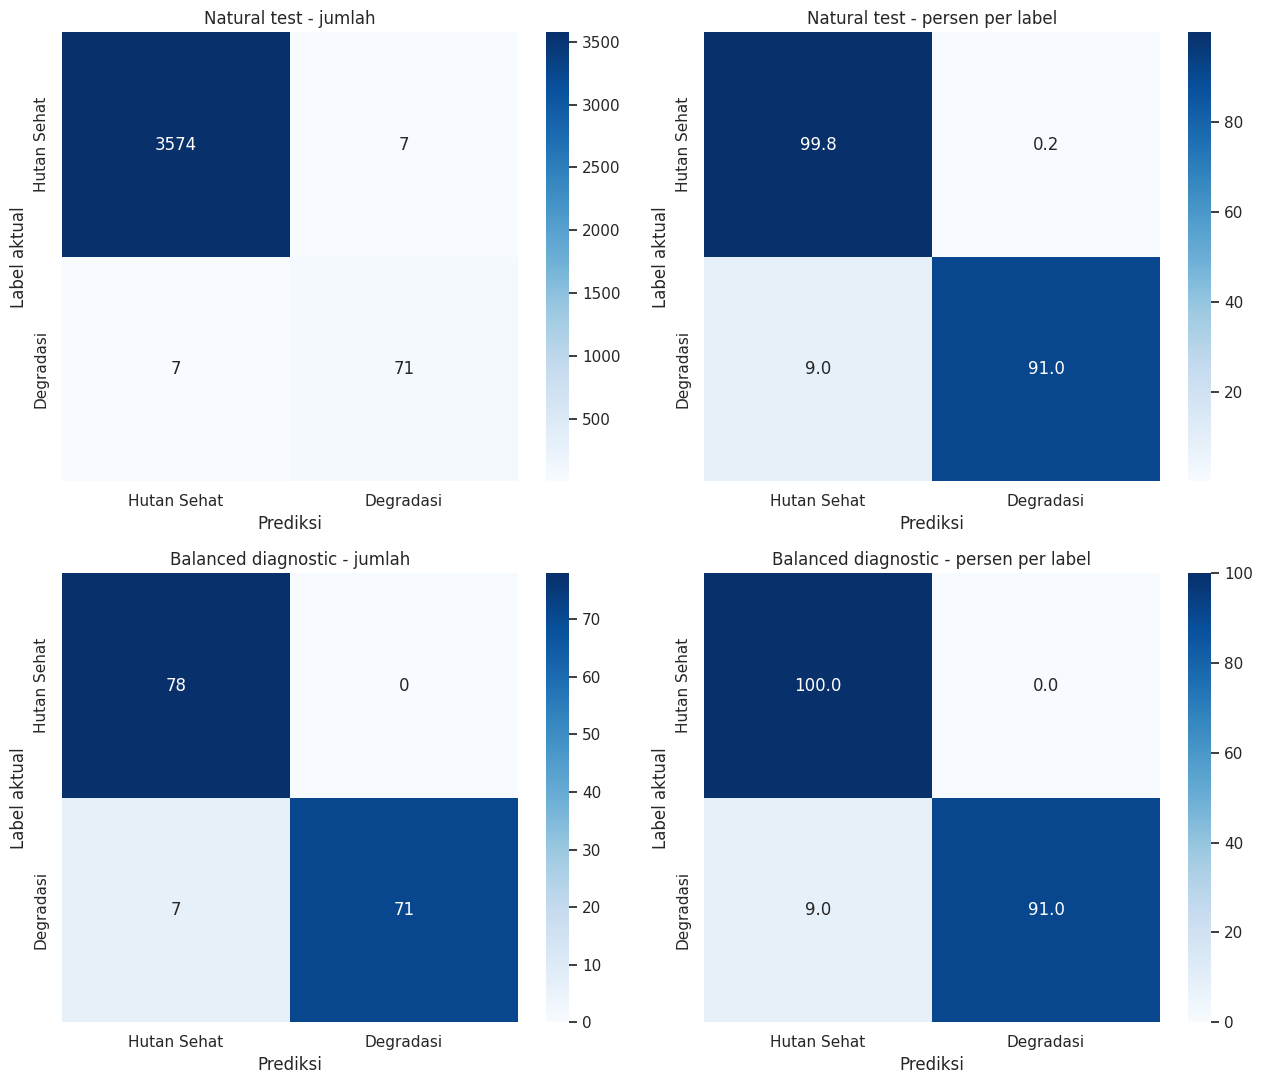

In [42]:
EVALUATION_METRIC_NAMES = [
    "accuracy",
    "balanced_accuracy",
    "precision_healthy",
    "recall_healthy",
    "f1_healthy",
    "precision_degradation",
    "recall_degradation",
    "f1_degradation",
    "specificity",
    "macro_f1",
    "weighted_f1",
    "mcc",
    "pr_auc",
    "roc_auc",
]

natural_metrics = {
    name: float(test_result[name]) for name in EVALUATION_METRIC_NAMES
}

# Balanced diagnostic subset 1:1 dicocokkan menurut bulan. Subset ini hanya
# diagnostik sekunder; natural test tetap menjadi evaluasi utama.
diagnostic_rng = np.random.default_rng(DIAGNOSTIC_SEED)
positive_positions = np.flatnonzero(test_result["targets"] == 1)
negative_positions = np.flatnonzero(test_result["targets"] == 0)
selected_negative_positions = []
used_negative_positions = set()

for target_month in sorted(
    test_predictions.iloc[positive_positions]["target_month"].unique()
):
    month_positive_positions = positive_positions[
        test_predictions.iloc[positive_positions]["target_month"].to_numpy()
        == target_month
    ]
    month_negative_candidates = negative_positions[
        test_predictions.iloc[negative_positions]["target_month"].to_numpy()
        == target_month
    ]
    month_negative_candidates = np.asarray([
        position for position in month_negative_candidates
        if int(position) not in used_negative_positions
    ], dtype=np.int64)
    required = len(month_positive_positions)
    take = min(required, len(month_negative_candidates))
    if take:
        chosen = diagnostic_rng.choice(
            month_negative_candidates, size=take, replace=False
        )
        selected_negative_positions.extend(chosen.tolist())
        used_negative_positions.update(int(x) for x in chosen)

remaining_required = len(positive_positions) - len(selected_negative_positions)
if remaining_required > 0:
    remaining_candidates = np.asarray([
        position for position in negative_positions
        if int(position) not in used_negative_positions
    ], dtype=np.int64)
    fallback = diagnostic_rng.choice(
        remaining_candidates, size=remaining_required, replace=False
    )
    selected_negative_positions.extend(fallback.tolist())

diagnostic_positions = np.concatenate([
    positive_positions,
    np.asarray(selected_negative_positions, dtype=np.int64),
])
diagnostic_rng.shuffle(diagnostic_positions)

diagnostic_targets = test_result["targets"][diagnostic_positions]
diagnostic_probabilities = test_result["probabilities"][diagnostic_positions]
diagnostic_predictions = test_result["predictions"][diagnostic_positions]
diagnostic_metrics = classification_metrics(
    diagnostic_targets,
    diagnostic_predictions,
    diagnostic_probabilities,
)

balanced_report = classification_report(
    diagnostic_targets,
    diagnostic_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
balanced_class_metrics = pd.DataFrame({
    "kelas": class_names,
    "precision": [
        balanced_report[class_names[0]]["precision"],
        balanced_report[class_names[1]]["precision"],
    ],
    "recall": [
        balanced_report[class_names[0]]["recall"],
        balanced_report[class_names[1]]["recall"],
    ],
    "f1_score": [
        balanced_report[class_names[0]]["f1-score"],
        balanced_report[class_names[1]]["f1-score"],
    ],
    "support": [
        int(balanced_report[class_names[0]]["support"]),
        int(balanced_report[class_names[1]]["support"]),
    ],
})
assert balanced_class_metrics["support"].nunique() == 1
balanced_class_metrics.to_csv(
    OUTPUT_DIR / "balanced_diagnostic_metrics_per_class.csv", index=False
)

combined_class_metrics = pd.concat([
    natural_class_metrics.assign(evaluation="natural_test_primary"),
    balanced_class_metrics.assign(evaluation="balanced_diagnostic_secondary"),
], ignore_index=True)
combined_class_metrics = combined_class_metrics[
    ["evaluation", "kelas", "precision", "recall", "f1_score", "support"]
]
combined_class_metrics.to_csv(
    OUTPUT_DIR / "natural_and_balanced_metrics_per_class.csv", index=False
)

diagnostic_predictions_table = (
    test_predictions.iloc[diagnostic_positions].copy().reset_index(drop=True)
)
diagnostic_predictions_table["diagnostic_subset"] = True
diagnostic_predictions_table.to_csv(
    OUTPUT_DIR / "balanced_diagnostic_test_predictions.csv",
    index=False,
)

print("Metrik setiap kelas pada BALANCED DIAGNOSTIC test (1:1):")
display(balanced_class_metrics.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
}))
print(
    "Catatan: balanced diagnostic merupakan subset sekunder. "
    "Precision dan PR-AUC utama tetap dilaporkan dari natural test."
)

evaluation_comparison = pd.DataFrame([
    {
        "evaluation": "natural_test_primary",
        "n": len(test_result["targets"]),
        "healthy": int((test_result["targets"] == 0).sum()),
        "degradation": int((test_result["targets"] == 1).sum()),
        **natural_metrics,
    },
    {
        "evaluation": "balanced_diagnostic_secondary",
        "n": len(diagnostic_targets),
        "healthy": int((diagnostic_targets == 0).sum()),
        "degradation": int((diagnostic_targets == 1).sum()),
        **{
            name: float(diagnostic_metrics[name])
            for name in EVALUATION_METRIC_NAMES
        },
    },
])
evaluation_comparison.to_csv(
    OUTPUT_DIR / "natural_vs_balanced_diagnostic_metrics.csv",
    index=False,
)
print("Perbandingan metrik natural dan balanced diagnostic:")
display(evaluation_comparison)

# Cluster bootstrap natural test: satu unit sampling adalah grid_id.
bootstrap_rng = np.random.default_rng(BOOTSTRAP_SEED)
grid_to_positions = {
    str(grid_id): group.index.to_numpy(dtype=np.int64)
    for grid_id, group in test_predictions.groupby("grid_id", sort=False)
}
unique_test_grids = np.asarray(list(grid_to_positions), dtype=object)
bootstrap_rows = []

for iteration in tqdm(
    range(BOOTSTRAP_ITERATIONS),
    desc="Cluster bootstrap natural test",
    leave=False,
):
    sampled_grids = bootstrap_rng.choice(
        unique_test_grids,
        size=len(unique_test_grids),
        replace=True,
    )
    sampled_positions = np.concatenate([
        grid_to_positions[str(grid_id)] for grid_id in sampled_grids
    ])
    sampled_targets = test_result["targets"][sampled_positions]
    if len(np.unique(sampled_targets)) < 2:
        continue
    sampled_metrics = classification_metrics(
        sampled_targets,
        test_result["predictions"][sampled_positions],
        test_result["probabilities"][sampled_positions],
    )
    bootstrap_rows.append({
        "iteration": iteration,
        **{
            name: float(sampled_metrics[name])
            for name in EVALUATION_METRIC_NAMES
        },
    })

bootstrap_distribution = pd.DataFrame(bootstrap_rows)
bootstrap_distribution.to_csv(
    OUTPUT_DIR / "bootstrap_test_distribution.csv",
    index=False,
)

bootstrap_ci = pd.DataFrame([
    {
        "metric": metric_name,
        "estimate": natural_metrics[metric_name],
        "ci_2_5": float(bootstrap_distribution[metric_name].quantile(0.025)),
        "bootstrap_median": float(
            bootstrap_distribution[metric_name].quantile(0.5)
        ),
        "ci_97_5": float(bootstrap_distribution[metric_name].quantile(0.975)),
        "valid_iterations": int(
            bootstrap_distribution[metric_name].notna().sum()
        ),
    }
    for metric_name in EVALUATION_METRIC_NAMES
])
bootstrap_ci.to_csv(
    OUTPUT_DIR / "bootstrap_test_95ci.csv",
    index=False,
)
print("95% confidence interval natural test (cluster bootstrap grid_id):")
display(bootstrap_ci)

natural_cm = confusion_matrix(
    test_result["targets"], test_result["predictions"], labels=[0, 1]
)
diagnostic_cm = confusion_matrix(
    diagnostic_targets, diagnostic_predictions, labels=[0, 1]
)
natural_cm_percent = (
    natural_cm / np.clip(natural_cm.sum(axis=1, keepdims=True), 1, None) * 100
)
diagnostic_cm_percent = (
    diagnostic_cm
    / np.clip(diagnostic_cm.sum(axis=1, keepdims=True), 1, None)
    * 100
)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for axis, matrix, title, value_format in (
    (axes[0, 0], natural_cm, "Natural test - jumlah", "d"),
    (axes[0, 1], natural_cm_percent, "Natural test - persen per label", ".1f"),
    (axes[1, 0], diagnostic_cm, "Balanced diagnostic - jumlah", "d"),
    (
        axes[1, 1],
        diagnostic_cm_percent,
        "Balanced diagnostic - persen per label",
        ".1f",
    ),
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=value_format,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel("Prediksi")
    axis.set_ylabel("Label aktual")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "natural_and_diagnostic_confusion_matrices.png",
    dpi=190,
    bbox_inches="tight",
)
plt.show()


## Bagian 4 — Explainability dan Penyimpanan Hasil


### 16. Bukti Degradasi Grad-CAM dan Perbandingan Temporal

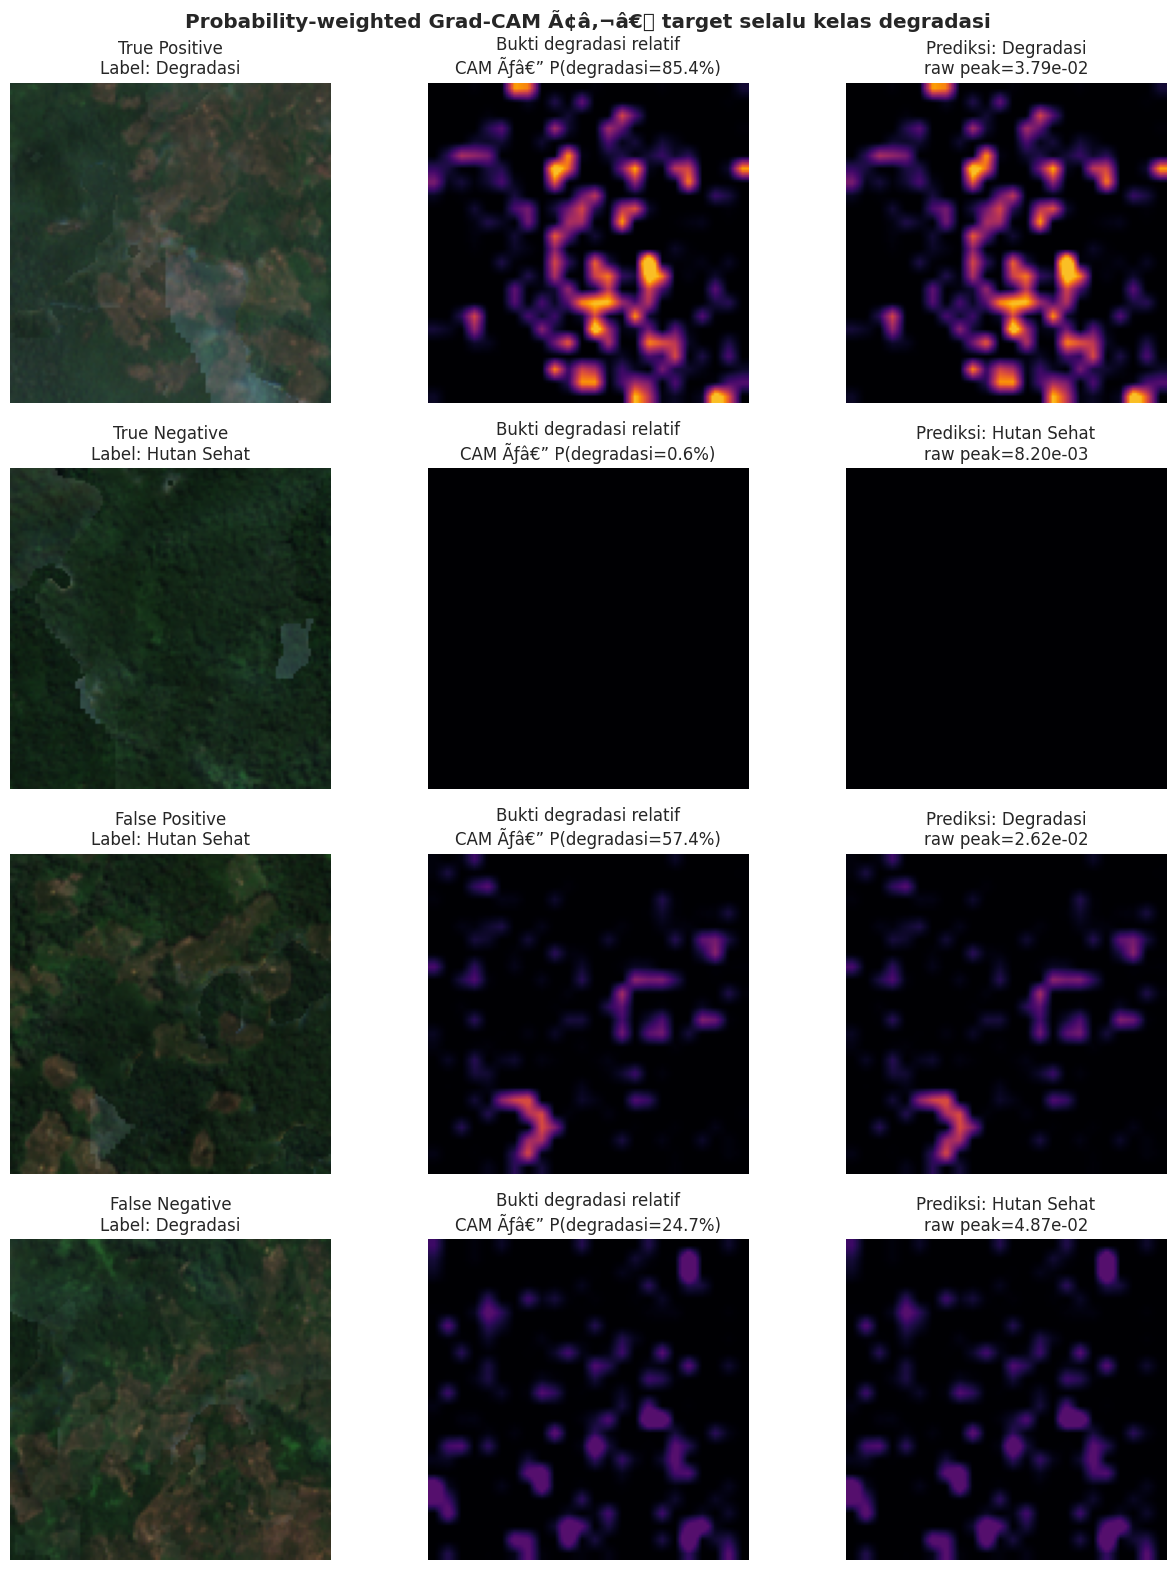

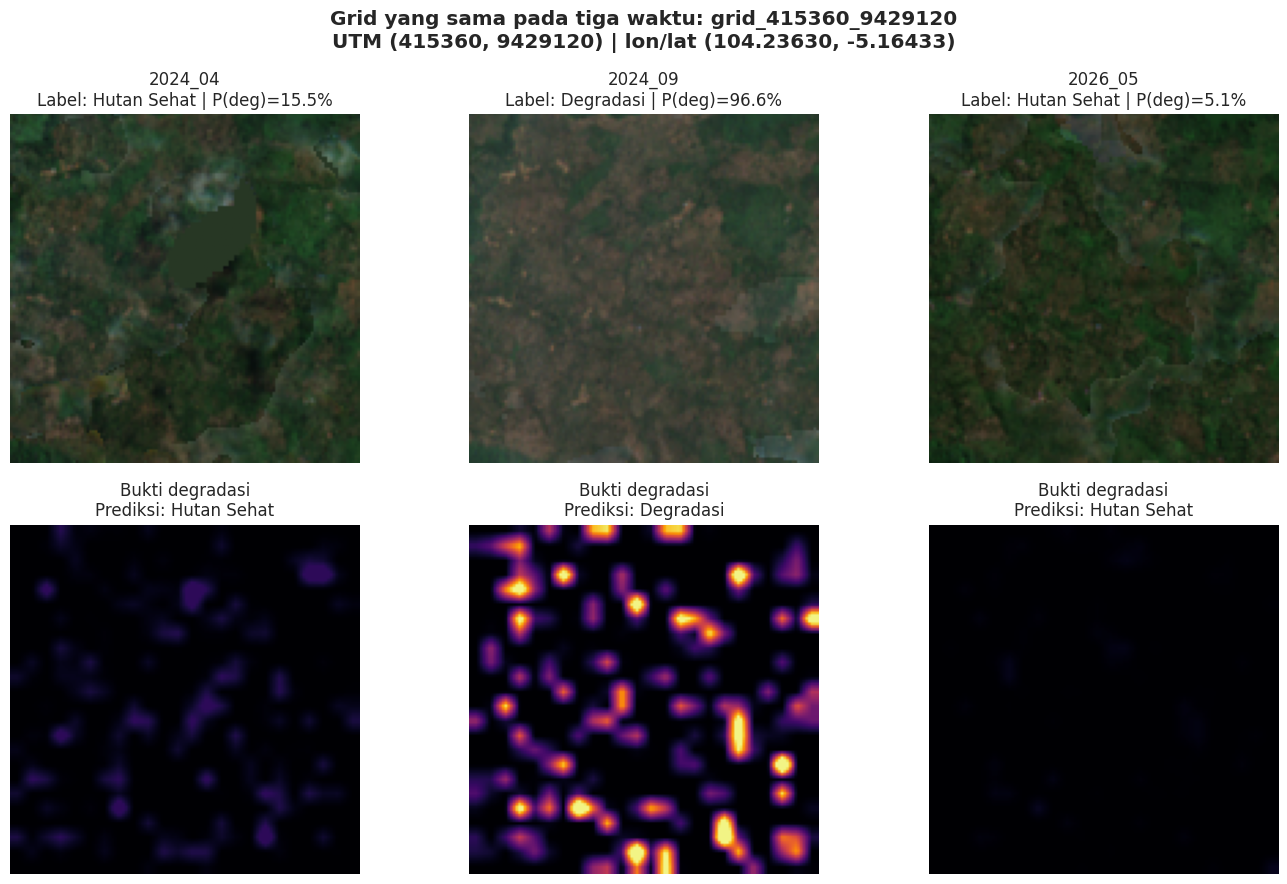

Grid temporal terpilih: grid_415360_9429120 | bulan: ['2024_04', '2024_09', '2026_05']


In [43]:
# Lepaskan hook dari eksekusi sebelumnya jika sel dijalankan ulang.
if "grad_cam" in globals():
    try:
        grad_cam.close()
    except Exception:
        pass


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(
            self._forward_hook
        )

    def _forward_hook(self, module, inputs, output):
        if not output.requires_grad:
            output = output.detach().requires_grad_(True)
        self.activations = output.detach()
        output.register_hook(self._save_gradient)
        return output

    def _save_gradient(self, gradient):
        self.gradients = gradient.detach()

    def _generate_raw(self, input_tensor, target_class=1):
        self.model.eval()
        input_tensor = input_tensor.to(DEVICE)
        self.model.zero_grad(set_to_none=True)
        self.gradients = None
        logits = self.model(input_tensor)
        probabilities = torch.softmax(logits.float(), dim=1)

        other_class = 1 - int(target_class)
        class_margin = logits[0, target_class] - logits[0, other_class]
        class_margin.backward()

        if self.gradients is None:
            raise RuntimeError("Gradien target layer tidak tertangkap.")

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        raw_cam = F.relu(
            (weights * self.activations).sum(dim=1, keepdim=True)
        )
        raw_cam = F.interpolate(
            raw_cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        return (
            raw_cam[0, 0],
            float(probabilities[0, target_class].item()),
            float(class_margin.detach().item()),
        )

    def generate_degradation_evidence(self, input_tensor):
        # Semua gambar menjelaskan kelas yang sama: degradasi (kelas 1).
        flip_dimensions = [(), (-1,), (-2,), (-2, -1)]
        restored_raw_cams = []
        probabilities = []
        margins = []

        for dimensions in flip_dimensions:
            transformed = (
                torch.flip(input_tensor, dims=dimensions)
                if dimensions else input_tensor
            )
            raw_cam, probability, margin = self._generate_raw(
                transformed, target_class=1
            )
            restored = (
                torch.flip(raw_cam, dims=dimensions)
                if dimensions else raw_cam
            )
            restored_raw_cams.append(restored)
            probabilities.append(probability)
            margins.append(margin)

        raw_cam = torch.stack(restored_raw_cams).mean(dim=0)
        return {
            "raw_cam": raw_cam.detach().cpu().numpy(),
            "degradation_probability_tta": float(np.mean(probabilities)),
            "degradation_margin_tta": float(np.mean(margins)),
            "raw_peak": float(raw_cam.max().detach().item()),
            "raw_mean": float(raw_cam.mean().detach().item()),
        }

    def close(self):
        self.forward_handle.remove()


def common_scale_and_weight(cam_results, probabilities):
    positive_values = [
        result["raw_cam"][result["raw_cam"] > 0]
        for result in cam_results
        if np.any(result["raw_cam"] > 0)
    ]
    if positive_values:
        global_scale = float(
            np.percentile(np.concatenate(positive_values), 99)
        )
    else:
        global_scale = 1.0
    global_scale = max(global_scale, 1e-12)

    weighted_maps = []
    for result, probability in zip(cam_results, probabilities):
        common_scaled = np.clip(
            result["raw_cam"] / global_scale, 0.0, 1.0
        )
        weighted_maps.append(common_scaled * float(probability))
    return weighted_maps, global_scale


case_masks = {
    "True Positive": (
        (test_result["targets"] == 1)
        & (test_result["predictions"] == 1)
    ),
    "True Negative": (
        (test_result["targets"] == 0)
        & (test_result["predictions"] == 0)
    ),
    "False Positive": (
        (test_result["targets"] == 0)
        & (test_result["predictions"] == 1)
    ),
    "False Negative": (
        (test_result["targets"] == 1)
        & (test_result["predictions"] == 0)
    ),
}

selected_cases = []
for case_name, mask in case_masks.items():
    positions = np.flatnonzero(mask)
    if len(positions):
        probabilities = test_result["probabilities"][positions]
        median_probability = float(np.median(probabilities))
        representative = int(
            positions[
                np.argmin(np.abs(probabilities - median_probability))
            ]
        )
        selected_cases.append((case_name, representative))

target_layer = model.backbone.features[5]
grad_cam = GradCAM(model, target_layer)

case_images = []
case_results = []
case_probabilities = []
for case_name, dataset_position in selected_cases:
    image_tensor, true_label = test_dataset[dataset_position]
    case_images.append(image_tensor)
    case_results.append(
        grad_cam.generate_degradation_evidence(
            image_tensor.unsqueeze(0)
        )
    )
    case_probabilities.append(
        float(test_result["probabilities"][dataset_position])
    )

case_weighted_maps, case_global_scale = common_scale_and_weight(
    case_results, case_probabilities
)

gradcam_audit_rows = []
if selected_cases:
    fig, axes = plt.subplots(
        len(selected_cases), 3,
        figsize=(13, 4 * len(selected_cases)),
    )
    if len(selected_cases) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, (
        (case_name, dataset_position),
        image_tensor,
        cam_result,
        weighted_cam,
    ) in enumerate(zip(
        selected_cases,
        case_images,
        case_results,
        case_weighted_maps,
    )):
        true_label = int(test_result["targets"][dataset_position])
        predicted_label = int(
            test_result["predictions"][dataset_position]
        )
        probability = float(
            test_result["probabilities"][dataset_position]
        )
        rgb = (
            image_tensor.float().div(255.0)
            .permute(1, 2, 0).numpy()
        )

        axes[row_index, 0].imshow(rgb)
        axes[row_index, 0].set_title(
            f"{case_name}\nLabel: {class_names[true_label]}"
        )
        axes[row_index, 1].imshow(
            weighted_cam, cmap="inferno", vmin=0, vmax=1
        )
        axes[row_index, 1].set_title(
            "Bukti degradasi relatif\n"
            f"CAM Ãƒâ€” P(degradasi={probability:.1%})"
        )
        axes[row_index, 2].imshow(rgb)
        axes[row_index, 2].imshow(
            weighted_cam,
            cmap="inferno",
            alpha=np.clip(weighted_cam * 0.75, 0, 0.75),
            vmin=0,
            vmax=1,
        )
        axes[row_index, 2].set_title(
            f"Prediksi: {class_names[predicted_label]}\n"
            f"raw peak={cam_result['raw_peak']:.2e}"
        )
        for axis in axes[row_index]:
            axis.axis("off")

        metadata_row = test_predictions.iloc[dataset_position]
        gradcam_audit_rows.append({
            "case": case_name,
            "grid_id": metadata_row["grid_id"],
            "target_month": metadata_row["target_month"],
            "true_label": true_label,
            "predicted_label": predicted_label,
            "degradation_probability": probability,
            "raw_peak": cam_result["raw_peak"],
            "raw_mean": cam_result["raw_mean"],
            "global_raw_scale": case_global_scale,
            "weighted_peak": float(weighted_cam.max()),
        })

    plt.suptitle(
        "Probability-weighted Grad-CAM Ã¢â‚¬â€ target selalu kelas degradasi",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "gradcam_degradation_evidence.png",
        dpi=190,
        bbox_inches="tight",
    )
    plt.show()

pd.DataFrame(gradcam_audit_rows).to_csv(
    OUTPUT_DIR / "gradcam_degradation_evidence.csv",
    index=False,
)


# Tiga waktu dari grid test yang sama.
grid_temporal_summary = (
    test_predictions.groupby("grid_id", as_index=False)
    .agg(
        observation_count=("target_month", "size"),
        label_variation=("true_label", "nunique"),
        probability_min=("degradation_probability", "min"),
        probability_max=("degradation_probability", "max"),
        degradation_count=("true_label", "sum"),
    )
)
grid_temporal_summary["probability_range"] = (
    grid_temporal_summary["probability_max"]
    - grid_temporal_summary["probability_min"]
)
eligible_temporal_grids = grid_temporal_summary.loc[
    grid_temporal_summary["observation_count"] >= 3
].copy()

if len(eligible_temporal_grids):
    selected_grid_id = (
        eligible_temporal_grids.sort_values(
            [
                "label_variation",
                "probability_range",
                "observation_count",
            ],
            ascending=[False, False, False],
        )
        .iloc[0]["grid_id"]
    )
    temporal_rows = (
        test_predictions.loc[
            test_predictions["grid_id"] == selected_grid_id
        ]
        .sort_values(["year", "month"])
        .copy()
    )
    temporal_positions_all = temporal_rows.index.to_numpy(dtype=np.int64)
    first_position = int(temporal_positions_all[0])
    last_position = int(temporal_positions_all[-1])
    peak_position = int(
        temporal_rows["degradation_probability"].idxmax()
    )
    selected_temporal_positions = []
    for position in (first_position, peak_position, last_position):
        if position not in selected_temporal_positions:
            selected_temporal_positions.append(position)
    if len(selected_temporal_positions) < 3:
        middle_position = int(
            temporal_positions_all[len(temporal_positions_all) // 2]
        )
        if middle_position not in selected_temporal_positions:
            selected_temporal_positions.append(middle_position)
    for position in temporal_positions_all:
        if len(selected_temporal_positions) >= 3:
            break
        if int(position) not in selected_temporal_positions:
            selected_temporal_positions.append(int(position))
    selected_temporal_positions = sorted(
        selected_temporal_positions[:3],
        key=lambda position: (
            int(test_predictions.iloc[position]["year"]),
            int(test_predictions.iloc[position]["month"]),
        ),
    )

    temporal_images = []
    temporal_cam_results = []
    temporal_probabilities = []
    for position in selected_temporal_positions:
        image_tensor, _ = test_dataset[position]
        temporal_images.append(image_tensor)
        temporal_cam_results.append(
            grad_cam.generate_degradation_evidence(
                image_tensor.unsqueeze(0)
            )
        )
        temporal_probabilities.append(
            float(test_result["probabilities"][position])
        )

    temporal_weighted_maps, temporal_global_scale = (
        common_scale_and_weight(
            temporal_cam_results,
            temporal_probabilities,
        )
    )

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    temporal_export_rows = []
    for column, (
        position,
        image_tensor,
        cam_result,
        weighted_cam,
    ) in enumerate(zip(
        selected_temporal_positions,
        temporal_images,
        temporal_cam_results,
        temporal_weighted_maps,
    )):
        row = test_predictions.iloc[position]
        rgb = (
            image_tensor.float().div(255.0)
            .permute(1, 2, 0).numpy()
        )
        probability = float(row["degradation_probability"])

        axes[0, column].imshow(rgb)
        axes[0, column].set_title(
            f"{row['target_month']}\n"
            f"Label: {class_names[int(row['true_label'])]} | "
            f"P(deg)={probability:.1%}"
        )
        axes[1, column].imshow(rgb)
        axes[1, column].imshow(
            weighted_cam,
            cmap="inferno",
            alpha=np.clip(weighted_cam * 0.75, 0, 0.75),
            vmin=0,
            vmax=1,
        )
        axes[1, column].set_title(
            "Bukti degradasi\n"
            f"Prediksi: {class_names[int(row['predicted_label'])]}"
        )
        axes[0, column].axis("off")
        axes[1, column].axis("off")

        export_row = row.to_dict()
        export_row.update({
            "raw_cam_peak": cam_result["raw_peak"],
            "raw_cam_mean": cam_result["raw_mean"],
            "temporal_global_scale": temporal_global_scale,
            "weighted_cam_peak": float(weighted_cam.max()),
        })
        temporal_export_rows.append(export_row)

    first_row = test_predictions.iloc[selected_temporal_positions[0]]
    plt.suptitle(
        f"Grid yang sama pada tiga waktu: {selected_grid_id}\n"
        f"UTM ({first_row['x_utm']:.0f}, {first_row['y_utm']:.0f}) | "
        f"lon/lat ({first_row['lon']:.5f}, {first_row['lat']:.5f})",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "temporal_same_grid_three_times.png",
        dpi=190,
        bbox_inches="tight",
    )
    plt.show()

    pd.DataFrame(temporal_export_rows).to_csv(
        OUTPUT_DIR / "temporal_same_grid_three_times.csv",
        index=False,
    )
    print(
        "Grid temporal terpilih:",
        selected_grid_id,
        "| bulan:",
        [
            test_predictions.iloc[position]["target_month"]
            for position in selected_temporal_positions
        ],
    )
else:
    print("Tidak ada grid test dengan sedikitnya tiga observasi.")

grad_cam.close()
